In [64]:
# CELDA 01
import subprocess, sys

IMPORT_MAP = {
    "scikit-learn": "sklearn",
    "statsmodels" : "statsmodels",
    "matplotlib"  : "matplotlib",
    "seaborn"     : "seaborn",
    "scipy"       : "scipy",
    "requests"    : "requests",
    "pandas"      : "pandas",
    "numpy"       : "numpy",
}

REQUIRED = [
    "requests", "pandas", "numpy", "scikit-learn",
    "matplotlib", "seaborn", "scipy", "statsmodels",
]

for pkg in REQUIRED:
    mod = IMPORT_MAP.get(pkg, pkg)
    try:
        __import__(mod)
    except ImportError:
        print(f"  Instalando {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("✓ Todas las dependencias disponibles")

✓ Todas las dependencias disponibles


In [65]:
# CELDA 02 
# Imports
import requests
import pandas as pd
import numpy as np
import warnings
import os
from datetime import datetime
from IPython.display import display, HTML
from sklearn.preprocessing   import StandardScaler
from sklearn.ensemble        import IsolationForest
from sklearn.neural_network  import MLPRegressor
from sklearn.decomposition   import PCA
from sklearn.metrics         import (roc_auc_score, precision_score,
                                     recall_score, f1_score,
                                     roc_curve)
from sklearn.dummy           import DummyClassifier
from scipy.stats               import shapiro, kurtosis, skew 
from statsmodels.tsa.stattools import adfuller, kpss
import matplotlib
import matplotlib.pyplot    as plt
import matplotlib.dates     as mdates
import matplotlib.patches   as mpatches
import matplotlib.gridspec  as gridspec
import matplotlib.ticker    as mticker
import seaborn              as sns
from matplotlib.colors      import LinearSegmentedColormap

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
matplotlib.rcParams["figure.dpi"]         = 130
matplotlib.rcParams["font.family"]        = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False

print(f"✓ Imports OK  |  pandas {pd.__version__}  |  numpy {np.__version__}")

✓ Imports OK  |  pandas 2.3.3  |  numpy 2.4.2


In [66]:
# CELDA 03
# Series BCRP
SERIES_CONFIG = {
    "PN06481IM": ("RIN_Millones_USD",   "Reservas int. netas (USD MM)",   "diff"),
    "PN01234PM": ("Tipo_Cambio_PEN",    "Tipo de cambio PEN/USD",         "pct"),
    "PN01271PM": ("IPC_Indice",         "IPC — indice de precios",        "pct"),
    "PN01770AM": ("PBI_Mensual_Indice", "PBI mensual (indice)",           "pct"),
    "PN38714BM": ("Exportaciones_MM",   "Exportaciones (USD MM)",         "pct"),
    "PN00208MM": ("M2_Soles_MM",        "Liquidez M2 (PEN MM)",           "pct"),
}
 
# Período
from datetime import datetime
PERIODO_INICIO  = "2005-01"
PERIODO_FIN = datetime.now().strftime("%Y-%m")

# Hiperparámetros EWS
BURN_IN         = 60          # 5 años de calentamiento
REFIT_FREQ      = 6           # re-estimar modelos cada N meses
CONTAMINATION   = 0.08        # fracción esperada de anomalías para IForest
HORIZONTE_EWS   = 6           # meses mínimos de anticipación aceptables
W_IF            = 0.8         # peso solationForest en score compuesto
W_AE            = 0.2         # peso Autoencoder
UMBRAL_SIGMA    = 1.5         # nº de sigmas sobre media para umbral adaptativo
EWMA_SPAN       = 3           # suavizado exponencial del score
ALERTA_PERSIST  = 2           # meses consecutivos mínimos para confirmar alerta
 
# Episodios de referencia
CRISIS_EPISODES = {
    "Crisis financiera\nglobal 2008": ("2008-09", "2009-06"),
    "Volatilidad\ncambiaria 2015":    ("2015-06", "2016-03"),
    "COVID-19\n2020":                 ("2020-03", "2021-09"),
}
 
P = {
    "primary"  : "#003f7f",
    "secondary": "#c0392b",
    "accent"   : "#e67e22",
    "green"    : "#1e8449",
    "neutral"  : "#7f8c8d",
    "bg"       : "#f5f5f0",
    "grid"     : "#dddddd",
    "text"     : "#1a1a1a",
    "light"    : "#d6eaf8",
}
 
OUTPUT_DIR = "output_ews"
os.makedirs(OUTPUT_DIR, exist_ok=True)
stats_df = pd.DataFrame()
 
display(HTML(f"""<div style='background:#e8f4f8; border-left:4px solid #003f7f; padding:10px 16px; border-radius:4px; color:#1a1a1a;'>
<b>✓ Configuración cargada</b> — Período: {PERIODO_INICIO} a {PERIODO_FIN} | Burn-in: {BURN_IN}m | Score: {W_IF*100:.0f}/{W_AE*100:.0f} IF+AE
</div>"""))

OUTPUT_DIR = "output_ews"
os.makedirs(OUTPUT_DIR, exist_ok=True)

stats_df : pd.DataFrame = pd.DataFrame()

display(HTML(f"""<div style='background:#e8f4f8; border-left:4px solid #003f7f;
padding:10px 16px; border-radius:4px; color:#1a1a1a;'>
<b>✓ Configuración cargada</b> — Burn-in: 60m | Refit: 6m |
IForest contam: 8% | Score: {W_IF*100:.0f}/{W_AE*100:.0f} IF+AE
</div>"""))

In [67]:
# CELDA 04
from typing import Optional

def parse_fecha_bcrp(fecha_str: str) -> Optional[pd.Timestamp]:
    meses_es = {
        "Ene":"Jan","Feb":"Feb","Mar":"Mar","Abr":"Apr","May":"May","Jun":"Jun",
        "Jul":"Jul","Ago":"Aug","Set":"Sep","Sep":"Sep","Oct":"Oct","Nov":"Nov","Dic":"Dec"
    }

    s = fecha_str.strip().replace(".", "")
    for es, en in meses_es.items():
        s = s.replace(es, en)
    for fmt in ("%b%Y","%b%y","%b %Y","%B%Y"):
        try:
            return pd.to_datetime(s, format=fmt)
        except (ValueError, TypeError):
            pass
    try:
        return pd.to_datetime(s)
    except Exception:
        return None

def descargar_serie(codigo: str, nombre: str) -> Optional[pd.DataFrame]:  

    url = (
        f"https://estadisticas.bcrp.gob.pe/estadisticas/observables/api/"
        f"{codigo}/json/{PERIODO_INICIO}/{PERIODO_FIN}"
    )

    try:
        r = requests.get(url, timeout=25)
        r.raise_for_status()
        datos  = r.json()
        periodos = datos.get("periods", [])
        if not periodos:
            print(f"Sin datos: {nombre}")
            return None
        fechas  = [parse_fecha_bcrp(p["name"]) for p in periodos]
        valores = []
        for p in periodos:
            try:
                v = float(str(p["values"][0]).replace(",",""))
            except (ValueError, IndexError):
                v = np.nan
            valores.append(v)

        df = pd.DataFrame({"Fecha": fechas, nombre: valores})
        df = df.dropna(subset=["Fecha"]).set_index("Fecha").sort_index()
        n_na = df[nombre].isna().sum()
        pct_na = n_na / len(df) * 100

        print(f"✓{nombre:32s} | obs={len(df):4d}  "
              f"| NaN={n_na} ({pct_na:.1f}%)  "
              f"| {df.index[0].strftime('%Y-%m')}→{df.index[-1].strftime('%Y-%m')}")
        return df

    except Exception as e:
        print(f"Error en {nombre}: {e}")
        return None

In [68]:
# CELDA 05
from typing import Optional

def parse_fecha_bcrp(fecha_str: str) -> Optional[pd.Timestamp]:
    meses_es = {
        "Ene":"Jan","Feb":"Feb","Mar":"Mar","Abr":"Apr","May":"May","Jun":"Jun",
        "Jul":"Jul","Ago":"Aug","Set":"Sep","Sep":"Sep","Oct":"Oct","Nov":"Nov","Dic":"Dec"
    }
    s = fecha_str.strip().replace(".", "")
    for es, en in meses_es.items():
        s = s.replace(es, en)
    for fmt in ("%b%Y", "%b%y", "%b %Y", "%B%Y"):
        try:
            return pd.to_datetime(s, format=fmt)
        except (ValueError, TypeError):
            pass
    try:
        return pd.to_datetime(s)
    except Exception:
        return None


def descargar_serie(codigo: str, nombre: str) -> Optional[pd.DataFrame]:
    url = (
        f"https://estadisticas.bcrp.gob.pe/estadisticas/series/api/"
        f"{codigo}/json/{PERIODO_INICIO}/{PERIODO_FIN}"
    )
    try:
        r = requests.get(url, timeout=25)
        r.raise_for_status()
        periodos = r.json().get("periods", [])
        if not periodos:
            print(f"Sin datos: {nombre}")
            return None

        fechas  = [parse_fecha_bcrp(p["name"]) for p in periodos]
        valores = []
        for p in periodos:
            try:
                v = float(str(p["values"][0]).replace(",", ""))
            except (ValueError, IndexError):
                v = np.nan
            valores.append(v)

        df = pd.DataFrame({"Fecha": fechas, nombre: valores})
        df = df.dropna(subset=["Fecha"]).set_index("Fecha").sort_index()

        if df.empty:
            print(f"⚠ {nombre}: DataFrame vacío tras parsear fechas")
            return None

        n_na    = df[nombre].isna().sum()
        pct_na  = n_na / len(df) * 100
        print(f"  ✓  {nombre:32s} | obs={len(df):4d}"
              f" | NaN={n_na} ({pct_na:.1f}%)"
              f" | {df.index[0].strftime('%Y-%m')}→{df.index[-1].strftime('%Y-%m')}")
        return df

    except Exception as e:
        print(f"✗ Error en {nombre}: {type(e).__name__}: {e}")
        return None


def construir_dataset() -> pd.DataFrame:
    print("=" * 65)
    print("  DESCARGA — API BCRP")
    print("=" * 65)
    frames = []
    for codigo, (nombre, _, _) in SERIES_CONFIG.items():
        df = descargar_serie(codigo, nombre)
        if df is not None:
            frames.append(df)

    if not frames:
        raise RuntimeError(
            "No se descargó ninguna serie. Verifica:\n"
            "  1. Conexión a internet activa\n"
            "  2. API BCRP disponible: https://estadisticas.bcrp.gob.pe\n"
            "  3. Códigos de serie correctos en SERIES_CONFIG"
        )

    panel = pd.concat(frames, axis=1).sort_index()
    panel = panel.asfreq("MS")

    n_miss_pre  = panel.isna().sum().sum()
    panel       = panel.interpolate("linear").bfill().ffill()
    n_miss_post = panel.isna().sum().sum()
    panel       = panel.dropna(how="all")

    panel.to_csv(os.path.join(OUTPUT_DIR, "dataset_ews_bcrp.csv"))
    print(f"\n  Panel consolidado  : {panel.shape[0]} obs × {panel.shape[1]} series")
    print(f"  Missings imputados : {n_miss_pre} → {n_miss_post}")
    print(f"  Exportado          : {OUTPUT_DIR}/dataset_ews_bcrp.csv")
    return panel

df_raw = construir_dataset()

  DESCARGA — API BCRP
  ✓  RIN_Millones_USD                 | obs= 255 | NaN=0 (0.0%) | 2005-01→2026-03
  ✓  Tipo_Cambio_PEN                  | obs= 255 | NaN=0 (0.0%) | 2005-01→2026-03
  ✓  IPC_Indice                       | obs= 255 | NaN=0 (0.0%) | 2005-01→2026-03
  ✓  PBI_Mensual_Indice               | obs= 254 | NaN=0 (0.0%) | 2005-01→2026-02
  ✓  Exportaciones_MM                 | obs= 254 | NaN=0 (0.0%) | 2005-01→2026-02
  ✓  M2_Soles_MM                      | obs= 254 | NaN=0 (0.0%) | 2005-01→2026-02

  Panel consolidado  : 255 obs × 6 series
  Missings imputados : 3 → 0
  Exportado          : output_ews/dataset_ews_bcrp.csv


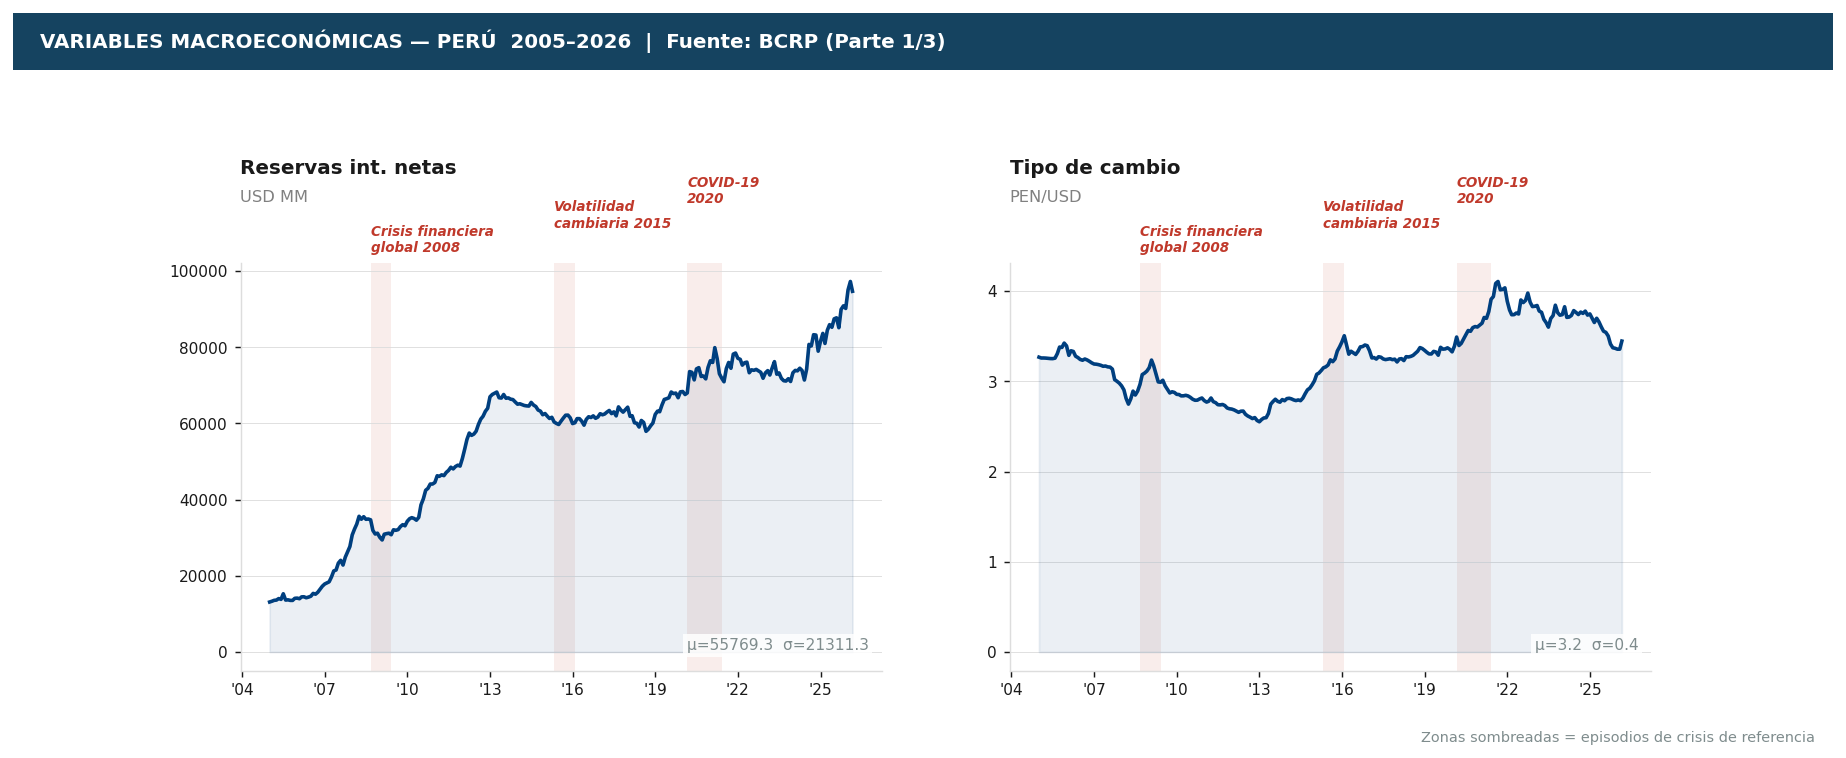

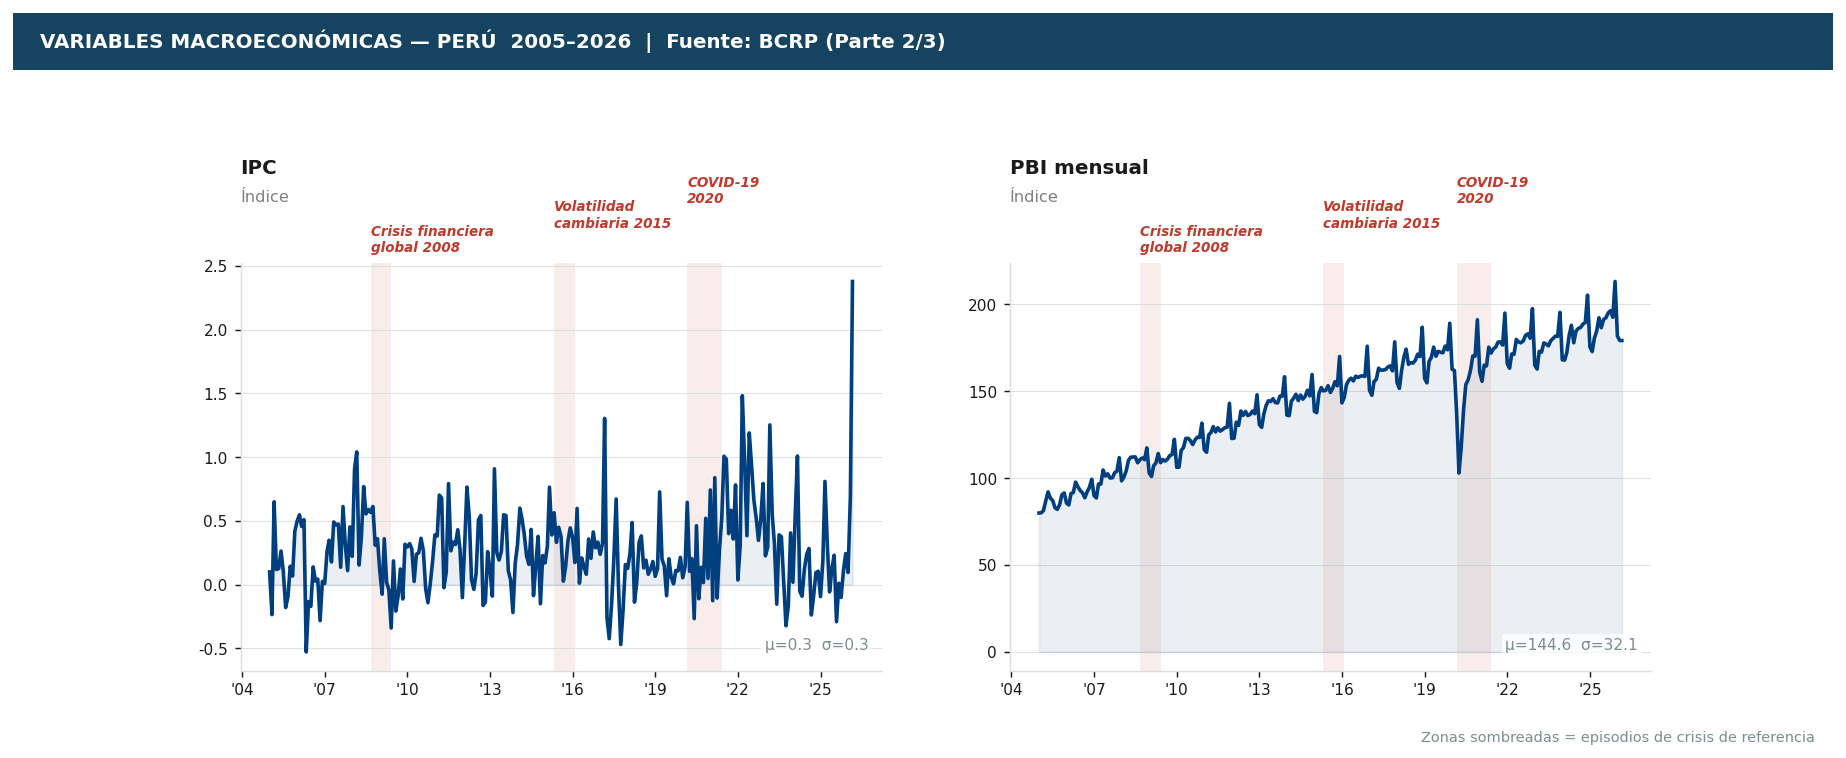

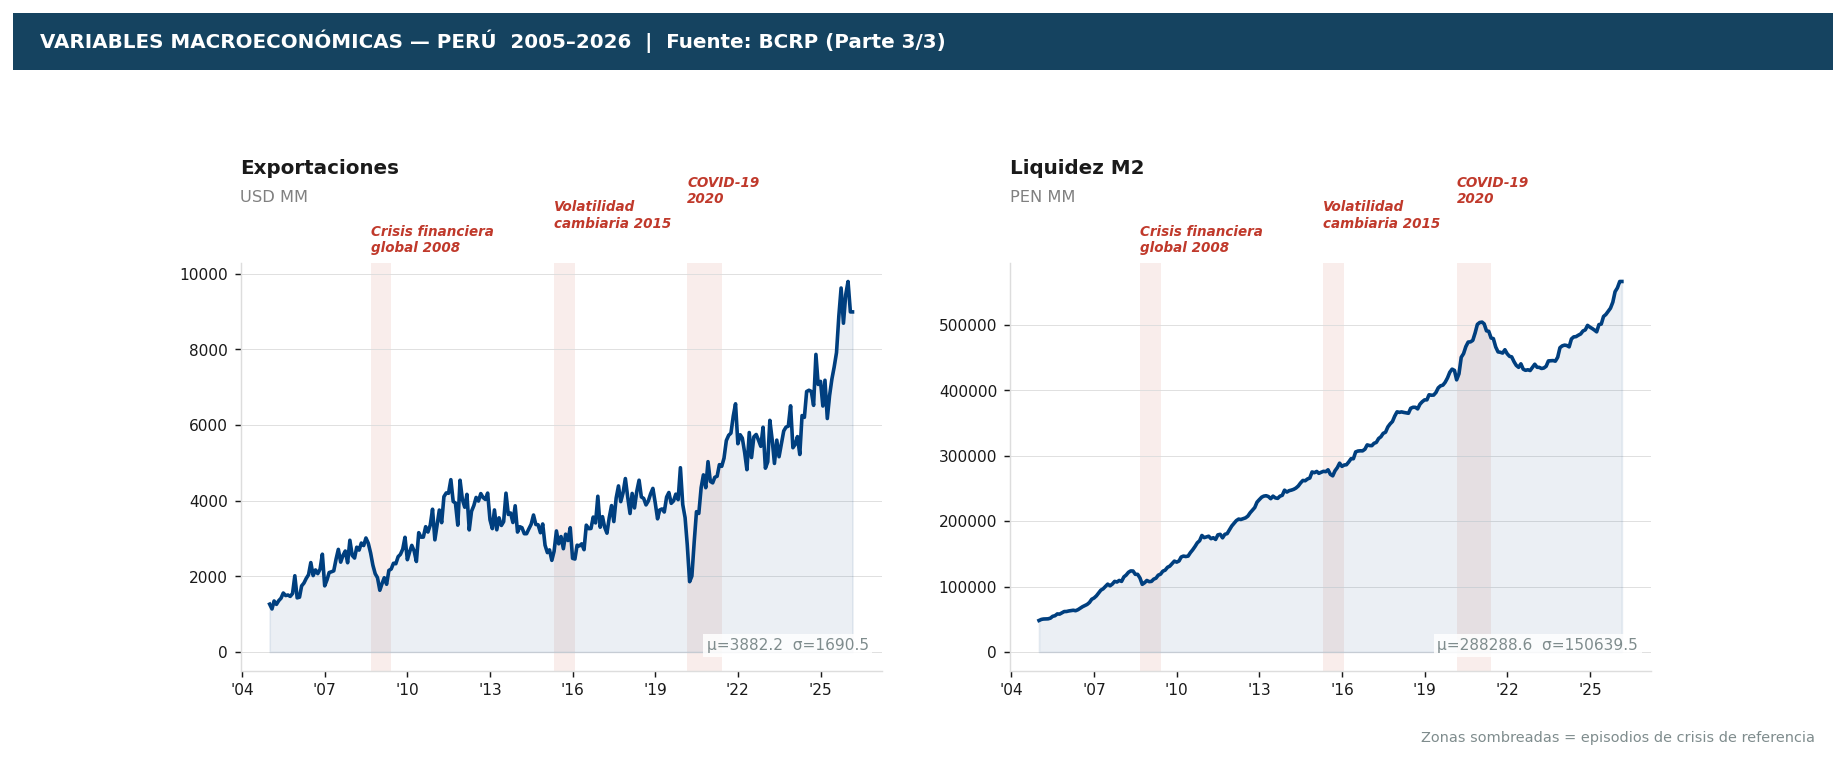

In [69]:
# CELDA 06
# 3.2 Gráfico de series macroeconómicas originales
CRISIS_EPISODES = {
    "Crisis financiera\nglobal 2008": ("2008-09-01", "2009-06-01"),
    "Volatilidad\ncambiaria 2015":    ("2015-05-01", "2016-02-01"),
    "COVID-19\n2020":                 ("2020-03-01", "2021-06-01")
}
def estilo_economist(ax, title: str = "", subtitle: str = "") -> None:
    ax.set_facecolor("white")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(P["grid"])
        
    ax.tick_params(colors=P["text"], labelsize=8.5)
    ax.yaxis.grid(True, color=P["grid"], linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    
    if title:
        ax.text(0.0, 1.22, title, transform=ax.transAxes, 
                fontsize=11, fontweight="bold", color=P["text"])
    if subtitle:
        ax.text(0.0, 1.15, subtitle, transform=ax.transAxes, 
                fontsize=9, color="gray")

def sombrear_crisis(ax, idx: pd.Index) -> None:
    trans_ax = ax.get_xaxis_transform()

    y_levels = [1.02, 1.08, 1.14]
    for level_idx, (nombre, (ini, fin)) in enumerate(CRISIS_EPISODES.items()):
        t0, t1 = pd.Timestamp(ini), pd.Timestamp(fin)
        if t0 >= idx[0] and t1 <= idx[-1]:
            ax.axvspan(t0, t1, color=P["secondary"], alpha=0.09, zorder=0, lw=0)
            t0_float = float(mdates.date2num(t0))
            y_pos = y_levels[level_idx % len(y_levels)]
            ax.text(
                t0_float, y_pos,
                nombre,                          # ya tiene \n incorporado
                fontsize=7.5, color=P["secondary"],
                va="bottom", ha="left",
                style="italic", fontweight="bold",
                clip_on=False, transform=trans_ax,
                linespacing=1.2
            )

series_plot = [
    ("RIN_Millones_USD",   "Reservas int. netas",  "USD MM"),
    ("Tipo_Cambio_PEN",    "Tipo de cambio",       "PEN/USD"),
    ("IPC_Indice",         "IPC",                  "Índice"),
    ("PBI_Mensual_Indice", "PBI mensual",          "Índice"),
    ("Exportaciones_MM",   "Exportaciones",        "USD MM"),
    ("M2_Soles_MM",        "Liquidez M2",          "PEN MM"),
]

available = [(n, l, u) for n, l, u in series_plot if n in df_raw.columns]

if not available:
    print("Ninguna de las series de series_plot está en df_raw.")
else:
    chunk_size = 2
    chunks = [available[i:i + chunk_size] for i in range(0, len(available), chunk_size)]

    for part_idx, chunk in enumerate(chunks, start=1):
        n_cols = len(chunk)
        
        fig, axes = plt.subplots(1, n_cols, figsize=(14, 5.5))
        fig.patch.set_facecolor("white")
        
        if n_cols == 1:
            axes = [axes]

        rect = mpatches.FancyBboxPatch(
            (0, 0.92), 1, 0.08, transform=fig.transFigure,
            boxstyle="square,pad=0", linewidth=0, facecolor="#154360"
        )
        fig.patches.append(rect)
        
        title_suffix = f" (Parte {part_idx}/{len(chunks)})" if len(chunks) > 1 else ""
        fig.text(0.015, 0.96,
                 f"VARIABLES MACROECONÓMICAS — PERÚ  2005–2026  |  Fuente: BCRP{title_suffix}",
                 color="white", fontsize=11, fontweight="bold",
                 transform=fig.transFigure, va="center")

        for i, (nombre, label, unidad) in enumerate(chunk):
            ax = axes[i]
            s = df_raw[nombre].dropna()
            
            ax.plot(s.index, s.values, color=P["primary"], lw=2.0, zorder=3)
            ax.fill_between(s.index, s.values, alpha=0.08, color=P["primary"])
            
            sombrear_crisis(ax, s.index)
            estilo_economist(ax, title=label, subtitle=unidad)
            
            ax.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))
            ax.xaxis.set_major_locator(mdates.YearLocator(3))
            
            ax.annotate(f"μ={s.mean():.1f}  σ={s.std():.1f}",
                        xy=(0.98, 0.05), xycoords="axes fraction",
                        ha="right", fontsize=8.5, color=P["neutral"],
                        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", pad=2.0))

        fig.text(0.99, -0.02, "Zonas sombreadas = episodios de crisis de referencia",
                 ha="right", fontsize=8, color=P["neutral"])
        
        fig.subplots_adjust(top=0.65, bottom=0.08, wspace=0.20)
        
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        filename = f"01_series_macroeconomicas_p{part_idx}.png" if len(chunks) > 1 else "01_series_macroeconomicas.png"
        plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=180, bbox_inches="tight")
        plt.show()

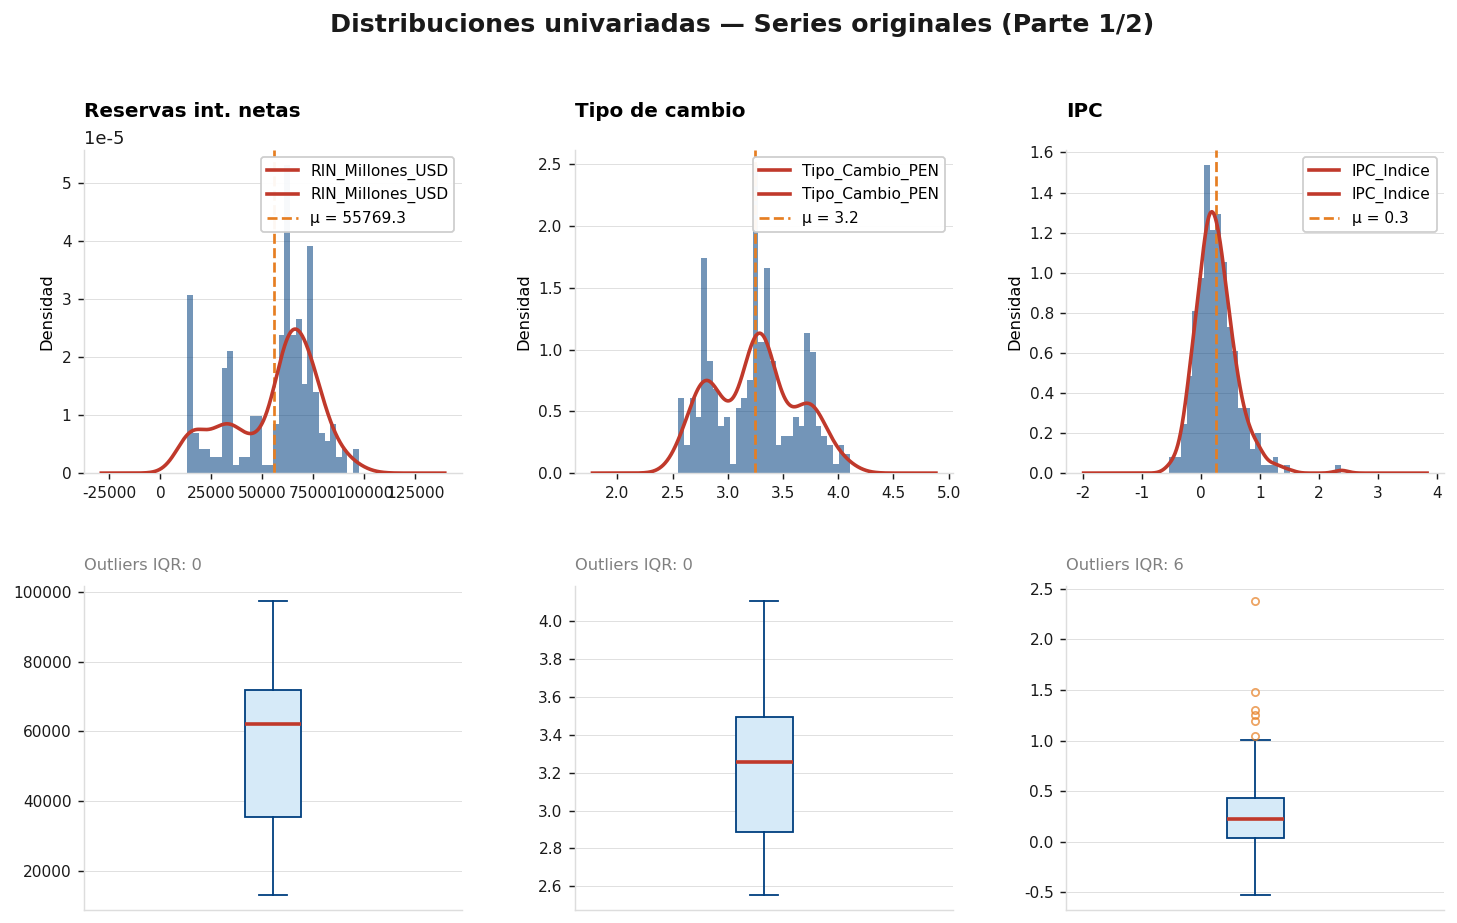

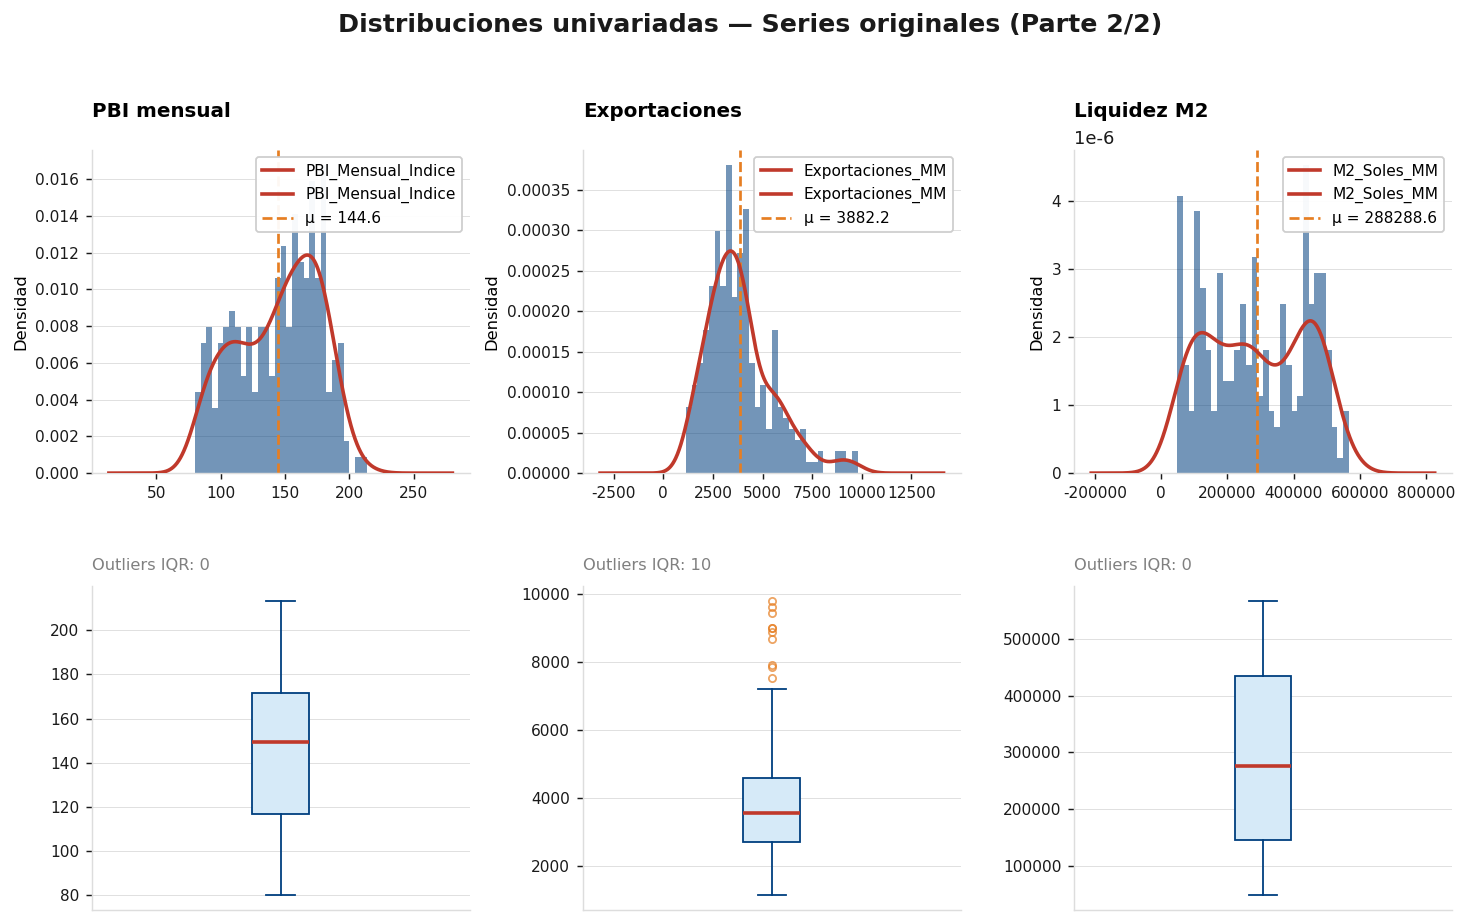

In [70]:
# CELDA 07
import os
import matplotlib.pyplot as plt
import numpy as np

# 3.3 Distribuciones
if available:
    chunk_size = 3
    chunks = [available[i:i + chunk_size] for i in range(0, len(available), chunk_size)]

    for part_idx, chunk in enumerate(chunks, start=1):
        n_cols = len(chunk)
        
        fig, axes = plt.subplots(2, n_cols, figsize=(4.5 * n_cols, 7.5))
        

        if n_cols == 1:
            axes = axes.reshape(2, 1)
            
        fig.patch.set_facecolor("white")
        
        # Título principal indicando la parte (si hay más de 1)
        title_suffix = f" (Parte {part_idx}/{len(chunks)})" if len(chunks) > 1 else ""
        fig.suptitle(f"Distribuciones univariadas — Series originales{title_suffix}",
                     fontsize=14, fontweight="bold", color=P["text"], y=1.02)

        for i, (nombre, label, _) in enumerate(chunk):
            s = df_raw[nombre].dropna()

            # Fila 0: Histograma + KDE
            ax = axes[0, i]          
            ax.plot([], [], color=P["secondary"], lw=2, label=nombre)           
            ax.hist(s, bins=30, color=P["primary"], alpha=0.55, density=True, zorder=2)
            s.plot.kde(ax=ax, color=P["secondary"], lw=2, zorder=3)
            ax.axvline(s.mean(), color=P["accent"], lw=1.5, ls="--",
                       label=f"μ = {s.mean():.1f}")         
            estilo_economist(ax)
            ax.text(0.0, 1.10, label, transform=ax.transAxes, fontsize=11, fontweight="bold")
            ax.legend(fontsize=8.5, loc="upper right", frameon=True, 
                      framealpha=0.95, edgecolor="#cccccc", fancybox=True)
            
            ax.set_ylabel("Densidad", fontsize=9)
            ax.set_xlabel("")

            # Fila 1: Boxplot
            ax2 = axes[1, i]
            ax2.boxplot(s, vert=True, patch_artist=True,
                        boxprops=dict(facecolor=P["light"], color=P["primary"]),
                        medianprops=dict(color=P["secondary"], lw=2),
                        whiskerprops=dict(color=P["primary"]),
                        capprops=dict(color=P["primary"]),
                        flierprops=dict(marker="o", markeredgecolor=P["accent"], 
                                        markerfacecolor="none", markersize=4, alpha=0.7))
            
            q1, q3 = s.quantile(0.25), s.quantile(0.75)
            iqr = q3 - q1
            n_out = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
            
            estilo_economist(ax2)
            ax2.text(0.0, 1.05, f"Outliers IQR: {n_out}", transform=ax2.transAxes, fontsize=9, color="gray")
            
            ax2.set_xticks([])

        fig.subplots_adjust(top=0.88, bottom=0.1, hspace=0.35, wspace=0.3)
        
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        filename = f"02_distribuciones_p{part_idx}.png" if len(chunks) > 1 else "02_distribuciones.png"
        plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=180, bbox_inches="tight")
        plt.show()

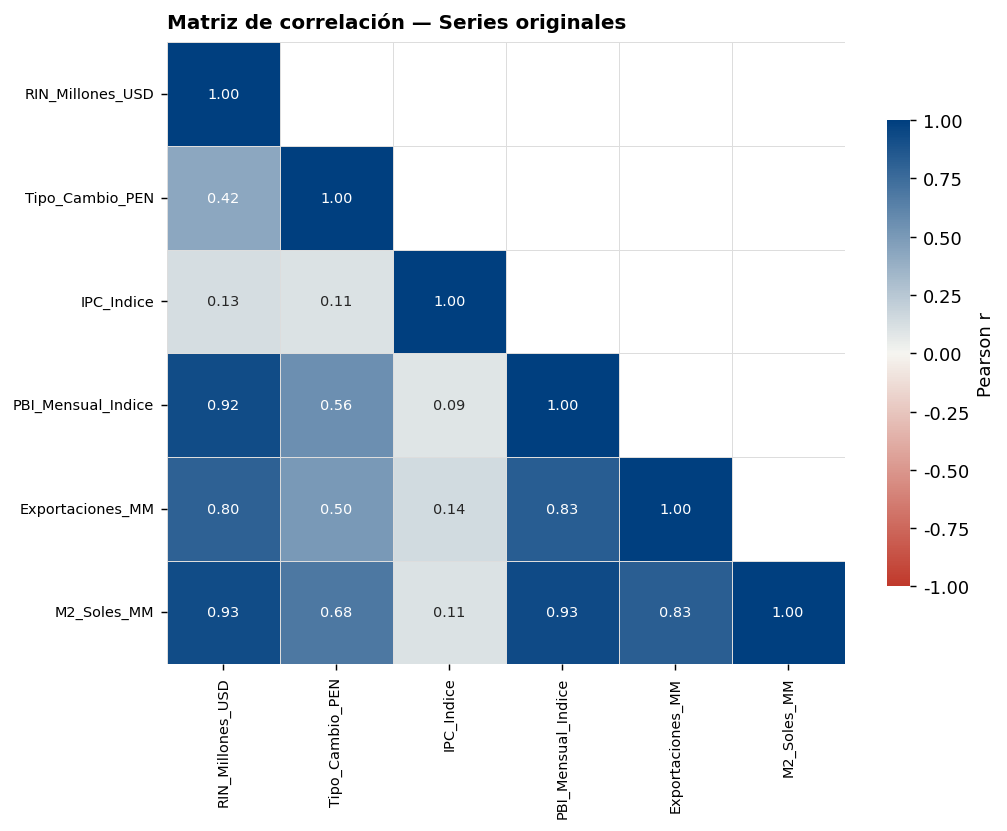


Interpretación: correlaciones altas (|r|>0.7) pueden indicar multicolinealidad.
El Autoencoder es robusto a esto; el IForest también (usa subsets de features).


In [71]:
# CELDA 08
# 3.4 Mapa de calor de correlaciones entre series originales
corr = df_raw.corr()
 
cmap_bcrp = LinearSegmentedColormap.from_list(
    "bcrp", ["#c0392b", "#f5f5f0", "#003f7f"], N=256
)
 
fig, ax = plt.subplots(figsize=(8, 6.5))
fig.patch.set_facecolor("white")
# Máscara triángulo superior (sin diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, ax=ax, annot=True, fmt=".2f",
            cmap=cmap_bcrp, center=0, vmin=-1, vmax=1,
            mask=mask,
            linewidths=0.5, linecolor=P["grid"],
            annot_kws={"size": 8},
            cbar_kws={"shrink": 0.75, "label": "Pearson r"})
ax.set_title("Matriz de correlación — Series originales",
             fontsize=11, fontweight="bold", loc="left", pad=8)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_correlacion_series.png"),
            dpi=180, bbox_inches="tight")
plt.show()
print("\nInterpretación: correlaciones altas (|r|>0.7) pueden indicar multicolinealidad.")
print("El Autoencoder es robusto a esto; el IForest también (usa subsets de features).")

In [72]:
# CELDA 09
def test_estacionariedad(series: pd.Series, nombre: str) -> dict:
    s = series.dropna()
    
    adf_res = adfuller(s, autolag="AIC")
    
    adf_stat = float(adf_res[0])
    adf_p    = float(adf_res[1])
    
    adf_lags = int(adf_res[2])  # pyright: ignore[reportArgumentType]

    kpss_stat, kpss_p, kpss_lags = np.nan, np.nan, np.nan
    try:
        kpss_res  = kpss(s, regression="c", nlags="auto")
        kpss_stat = float(kpss_res[0])
        kpss_p    = float(kpss_res[1])

        kpss_lags = int(kpss_res[2])  # pyright: ignore[reportArgumentType]
    except Exception:
        pass

    adf_estac  = bool(adf_p < 0.05)
    kpss_estac = (kpss_p > 0.05) if not np.isnan(kpss_p) else None

    if kpss_estac is None:
        veredicto = "Evidencia mixta (KPSS no disponible)"
    elif adf_estac and kpss_estac:
        veredicto = "Estacionaria"
    elif not adf_estac and not kpss_estac:
        veredicto = "No estacionaria (I≥1)"
    else:
        veredicto = "Evidencia mixta"

    return {
        "Serie"     : nombre,
        "ADF_stat"  : round(adf_stat, 4),
        "ADF_p"     : round(adf_p, 4),
        "ADF_lags"  : adf_lags,
        "KPSS_stat" : round(kpss_stat, 4) if not np.isnan(kpss_stat) else np.nan,
        "KPSS_p"    : round(kpss_p, 4)    if not np.isnan(kpss_p)    else np.nan,
        "Veredicto" : veredicto,
    }


resultados_tests = [
    test_estacionariedad(df_raw[nombre], nombre)
    for _, (nombre, _, _) in SERIES_CONFIG.items()
    if nombre in df_raw.columns
]

tests_df = pd.DataFrame(resultados_tests).set_index("Serie")

display(HTML("<h4 style='color:#003f7f'>Tests de estacionariedad — Series en niveles</h4>"))


def color_veredicto(val) -> str:
    s = str(val)
    if "Estacionaria" in s: return "background-color:#d5f5e3; font-weight:bold"
    if "No estacionaria" in s: return "background-color:#fadbd8; font-weight:bold"
    if "Evidencia mixta"  in s: return "background-color:#fef9e7; font-weight:bold"
    return ""


def color_pval(val) -> str:
    try:
        v = float(val)
        return "color:#c0392b; font-weight:bold" if v < 0.05 else "color:#1e8449"
    except (TypeError, ValueError):
        return ""


display(
    tests_df.style
    .map(color_veredicto, subset=["Veredicto"])
    .map(color_pval, subset=["ADF_p", "KPSS_p"])
    .format("{:.4f}", subset=["ADF_stat", "ADF_p", "KPSS_stat", "KPSS_p"],
            na_rep="—")
    .set_caption("ADF p<0.05 → rechaza raíz unitaria | KPSS p>0.05 → acepta estacionariedad")
)

n_est = tests_df["Veredicto"].str.contains("Estacionaria").sum()
print(f"\n{n_est}/{len(tests_df)} series estacionarias en niveles.")
print("   Las no estacionarias se transforman en la Sección 5 (pct_change / diff).")

,ADF_stat,ADF_p,ADF_lags,KPSS_stat,KPSS_p,Veredicto
Serie,,,,,,
RIN_Millones_USD,-1.1012,0.7146,15,2.1252,0.0100,No estacionaria (I≥1)
Tipo_Cambio_PEN,-1.2906,0.6335,3,1.4569,0.0100,No estacionaria (I≥1)
IPC_Indice,-3.2549,0.0170,13,0.1860,0.1000,Estacionaria
PBI_Mensual_Indice,-1.3594,0.6016,14,2.3115,0.0100,No estacionaria (I≥1)
Exportaciones_MM,0.7452,0.9907,15,1.8938,0.0100,No estacionaria (I≥1)
M2_Soles_MM,0.0337,0.9612,15,2.4109,0.0100,No estacionaria (I≥1)



1/6 series estacionarias en niveles.
   Las no estacionarias se transforman en la Sección 5 (pct_change / diff).


In [73]:
# CELDA 10
def transformar_series(df: pd.DataFrame) -> pd.DataFrame:
    feats = pd.DataFrame(index=df.index)
 
    for _, (nombre, _, transf) in SERIES_CONFIG.items():
        if nombre not in df.columns:
            continue
        s = df[nombre].copy()
 
        if transf == "pct":
            feats[f"{nombre}_yoy"] = s.pct_change(12) * 100
            feats[f"{nombre}_mom"] = s.pct_change(1)  * 100
        elif transf == "diff":
            feats[f"{nombre}_diff12"] = s.diff(12)
            feats[f"{nombre}_diff1"]  = s.diff(1)
 
        feats[f"{nombre}_vol12"]    = s.pct_change().rolling(12).std() * 100
        feats[f"{nombre}_momentum"] = (
            (s - s.rolling(24).mean()) / (s.rolling(24).std() + 1e-9)
        )
 
    # Ratios macroeconómicos
    if "RIN_Millones_USD" in df.columns and "M2_Soles_MM" in df.columns:
        # FIX: usar df["Tipo_Cambio_PEN"] si existe; de lo contrario escalar 3.3
        tc = df["Tipo_Cambio_PEN"] if "Tipo_Cambio_PEN" in df.columns \
             else pd.Series(3.3, index=df.index)
        feats["Cobertura_RIN_M2"] = (df["RIN_Millones_USD"] * tc) / df["M2_Soles_MM"]
 
    if "Exportaciones_MM" in df.columns and "RIN_Millones_USD" in df.columns:
        feats["Ratio_Exp_RIN"] = (
            df["Exportaciones_MM"] / df["RIN_Millones_USD"].replace(0, np.nan)
        )
 
    if "Tipo_Cambio_PEN" in df.columns:
        tc = df["Tipo_Cambio_PEN"]
        feats["TC_desviacion_2y"]  = (tc - tc.rolling(24).mean()) / (tc.rolling(24).std() + 1e-9)
        feats["TC_aceleracion"]    = tc.pct_change().diff()
        feats["TC_volatilidad_6m"] = tc.pct_change().rolling(6).std() * 100
 
    if "IPC_Indice" in df.columns and "M2_Soles_MM" in df.columns:
        feats["Brecha_MonetariaInflacion"] = (
            df["M2_Soles_MM"].pct_change(12) * 100
            - df["IPC_Indice"].pct_change(12) * 100
        )
 
    if "PBI_Mensual_Indice" in df.columns:
        pbi = df["PBI_Mensual_Indice"]
        feats["PBI_gap"] = (pbi - pbi.rolling(24).mean()) / (pbi.rolling(24).std() + 1e-9)
 
    feats = feats.dropna(thresh=int(feats.shape[1] * 0.6))
    feats = feats.fillna(feats.median())
 
    print(f"Features construidos : {feats.shape[1]} columnas")
    print(f"  Período efectivo     : {feats.index[0].strftime('%Y-%m')} "
          f"→ {feats.index[-1].strftime('%Y-%m')}")
    print(f"  Observaciones        : {feats.shape[0]}")
    return feats
 
 
feats = transformar_series(df_raw)
display(
    feats.describe().T.style
    .background_gradient(subset=["mean", "std"], cmap="Blues")
    .format("{:.4f}")
    .set_caption("Estadísticos de features transformados")
)

Features construidos : 31 columnas
  Período efectivo     : 2006-01 → 2026-03
  Observaciones        : 243


,count,mean,std,min,25%,50%,75%,max
RIN_Millones_USD_diff12,243.0000,3740.6051,5599.7624,-6612.1249,-827.5000,3039.8787,8289.7083,16186.0000
RIN_Millones_USD_diff1,243.0000,331.7670,1487.3710,-4241.1308,-442.0292,240.0000,913.5000,6493.4376
RIN_Millones_USD_vol12,243.0000,2.3864,1.0706,0.6685,1.5315,2.1352,3.1006,5.0882
RIN_Millones_USD_momentum,243.0000,0.7724,1.2635,-2.5247,0.0915,1.0903,1.7096,3.5929
Tipo_Cambio_PEN_yoy,243.0000,0.4694,6.2073,-13.5427,-3.9306,-0.3625,4.4037,15.5438
Tipo_Cambio_PEN_mom,243.0000,0.0121,1.3769,-3.7026,-0.6335,-0.1194,0.7133,4.1376
Tipo_Cambio_PEN_vol12,243.0000,1.2063,0.5461,0.2191,0.7469,1.0942,1.6364,2.3387
Tipo_Cambio_PEN_momentum,243.0000,-0.0467,1.3947,-2.7731,-1.1241,-0.1945,1.1453,3.0217
IPC_Indice_yoy,243.0000,17.7819,611.5742,-2362.3250,-116.5890,-40.4363,38.1704,5357.3166
IPC_Indice_mom,243.0000,44.2311,512.5347,-2065.8273,-102.9137,-29.2640,62.0260,3002.6078


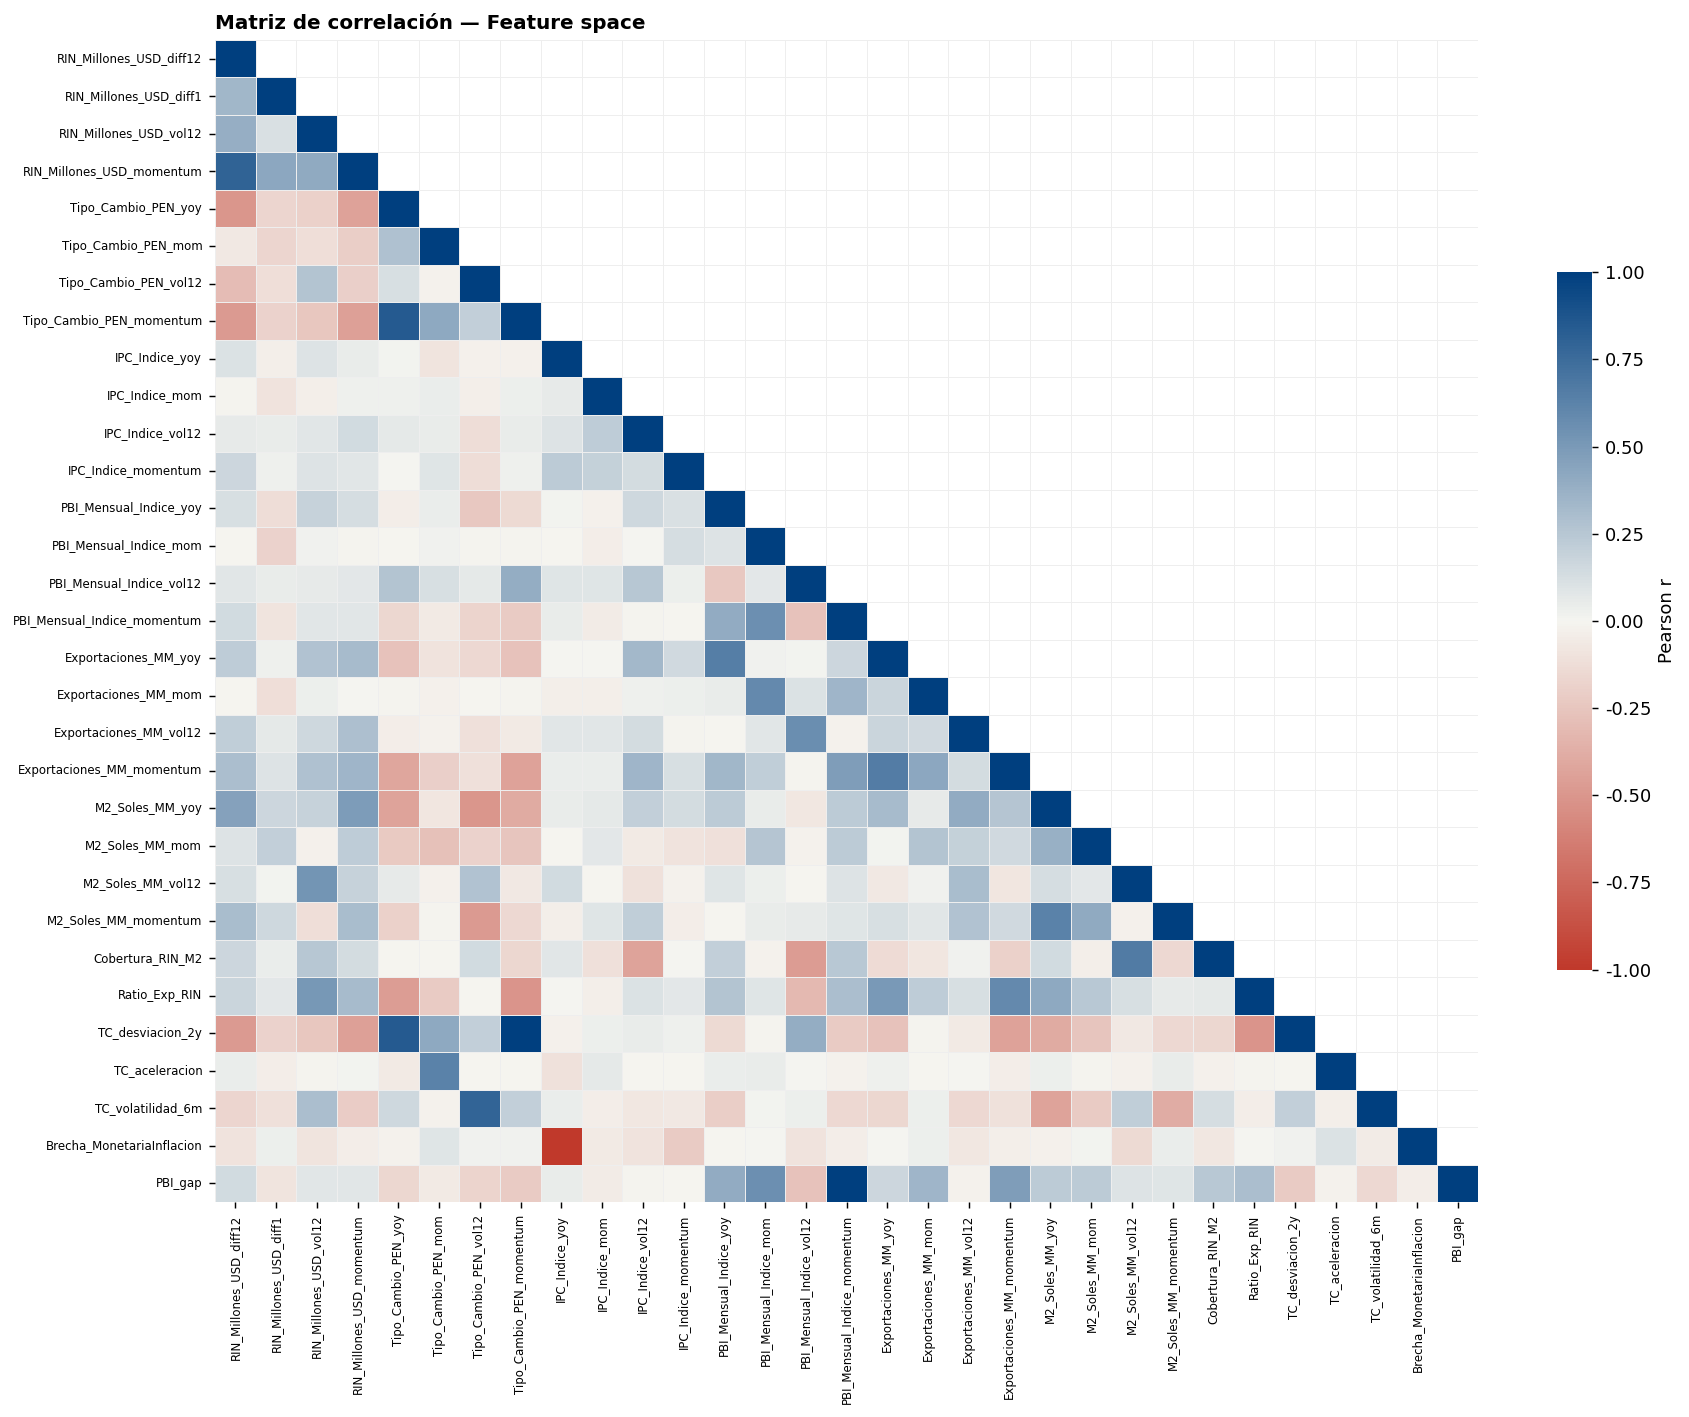

Feature space: 31 dimensiones antes de modeling.


In [74]:
# CELDA 11
# 5.1 Correlación features entre sí
fig, ax = plt.subplots(figsize=(14, 11))
fig.patch.set_facecolor("white")
corr_feats = feats.corr()
mask = np.triu(np.ones_like(corr_feats, dtype=bool), k=1)
sns.heatmap(corr_feats, ax=ax, cmap=cmap_bcrp,
            center=0, vmin=-1, vmax=1,
            mask=mask, linewidths=0.3, linecolor="#eeeeee",
            annot=False,
            cbar_kws={"shrink": 0.6, "label": "Pearson r"})
ax.set_title("Matriz de correlación — Feature space",
             fontsize=11, fontweight="bold", loc="left")
ax.tick_params(labelsize=6.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "04_correlacion_features.png"),
            dpi=180, bbox_inches="tight")
plt.show()
print(f"Feature space: {feats.shape[1]} dimensiones antes de modeling.")

In [75]:
# CELDA 12
# Fábricas de modelos
def _build_iforest() -> IsolationForest:
    return IsolationForest(
        n_estimators  = 150,
        contamination = CONTAMINATION,
        max_features  = 0.8,
        bootstrap     = True,
        random_state  = 42,
        n_jobs        = -1,
    )

def _build_autoencoder(n_feat: int) -> MLPRegressor:
    h = min(32, n_feat * 2)
    return MLPRegressor(
        hidden_layer_sizes  = (h, 16, 8, 4, 8, 16, h),
        activation          = "tanh",
        solver              = "adam",
        max_iter            = 600,
        learning_rate_init  = 5e-4,
        early_stopping      = True,
        validation_fraction = 0.1,
        n_iter_no_change    = 20,
        random_state        = 42,
        tol                 = 1e-4,
        verbose             = False,
    )

# Expanding window
def evaluar_expanding_window(
    feats: pd.DataFrame,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:
    n, p   = feats.shape
    X_raw  = feats.values.astype(float)

    if_scores    = np.full(n, np.nan)
    ae_errors    = np.full(n, np.nan)
    X_oos_sc     = np.full_like(X_raw, np.nan)
    scaler_means = np.full_like(X_raw, np.nan)

    iforest, autoenc, last_refit = None, None, None
    log_rows: list[dict] = []

    print("=" * 65)
    print(f"  EXPANDING WINDOW  |  Burn-in: {BURN_IN}m  |  Refit: {REFIT_FREQ}m")
    print("=" * 65)

    for t in range(BURN_IN, n):
        # 1. Scaler expansivo
        scaler = StandardScaler()
        X_train_sc      = scaler.fit_transform(X_raw[:t])
        X_eval_sc       = scaler.transform(X_raw[t : t + 1])
        X_oos_sc[t]     = X_eval_sc[0]
        scaler_means[t] = scaler.mean_

        # 2. Re-estimar modelos según frecuencia de refit
        necesita_refit = (last_refit is None) or ((t - last_refit) >= REFIT_FREQ)
        if necesita_refit:
            iforest = _build_iforest()
            iforest.fit(X_train_sc)
            autoenc = _build_autoencoder(p)
            autoenc.fit(X_train_sc, X_train_sc)
            last_refit = t

        # 3. Scores genuinamente out-of-sample
        assert iforest is not None and autoenc is not None
        if_scores[t] = iforest.score_samples(X_eval_sc)[0]
        X_rec        = autoenc.predict(X_eval_sc)
        ae_errors[t] = float(np.mean((X_eval_sc - X_rec) ** 2))
        if (t - BURN_IN) % 24 == 0:
            pct   = (t - BURN_IN) / (n - BURN_IN) * 100
            fecha = feats.index[t].strftime("%Y-%m")
            tag   = "↺ refit" if necesita_refit else ""
            print(f"  [{pct:5.1f}%] {fecha}  "
                  f"| IF={if_scores[t]:.4f}  AE_MSE={ae_errors[t]:.4f}  | {tag}")
            log_rows.append({
                "Fecha"    : fecha,
                "IF_Score" : if_scores[t],
                "AE_MSE"   : ae_errors[t],
                "Refit"    : bool(necesita_refit),
            })

    valid_if = if_scores[~np.isnan(if_scores)]
    valid_ae = ae_errors[~np.isnan(ae_errors)]
    print(f"\n  IF  — score medio : {valid_if.mean():.4f} | "
          f"p10: {np.percentile(valid_if, 10):.4f} | "
          f"p90: {np.percentile(valid_if, 90):.4f}")
    print(f"  AE  — MSE medio   : {valid_ae.mean():.4f} | "
          f"p95: {np.percentile(valid_ae, 95):.4f}")
    print(f"Evaluaciones oos genuinas: {(~np.isnan(if_scores)).sum()}")

    log_df = pd.DataFrame(log_rows).set_index("Fecha") if log_rows else pd.DataFrame()
    return if_scores, ae_errors, X_oos_sc, scaler_means, log_df


if_scores, ae_errors, X_oos_sc, scaler_means, log_df = evaluar_expanding_window(feats)

  EXPANDING WINDOW  |  Burn-in: 60m  |  Refit: 6m
  [  0.0%] 2011-01  | IF=-0.5164  AE_MSE=0.7854  | ↺ refit
  [ 13.1%] 2013-01  | IF=-0.5423  AE_MSE=0.8655  | ↺ refit
  [ 26.2%] 2015-01  | IF=-0.5659  AE_MSE=1.4861  | ↺ refit
  [ 39.3%] 2017-01  | IF=-0.5197  AE_MSE=0.6898  | ↺ refit
  [ 52.5%] 2019-01  | IF=-0.5321  AE_MSE=0.7749  | ↺ refit
  [ 65.6%] 2021-01  | IF=-0.6065  AE_MSE=2.5306  | ↺ refit
  [ 78.7%] 2023-01  | IF=-0.5276  AE_MSE=0.5247  | ↺ refit
  [ 91.8%] 2025-01  | IF=-0.4929  AE_MSE=0.6024  | ↺ refit

  IF  — score medio : -0.5076 | p10: -0.5512 | p90: -0.4720
  AE  — MSE medio   : 1.0848 | p95: 3.0970
Evaluaciones oos genuinas: 183


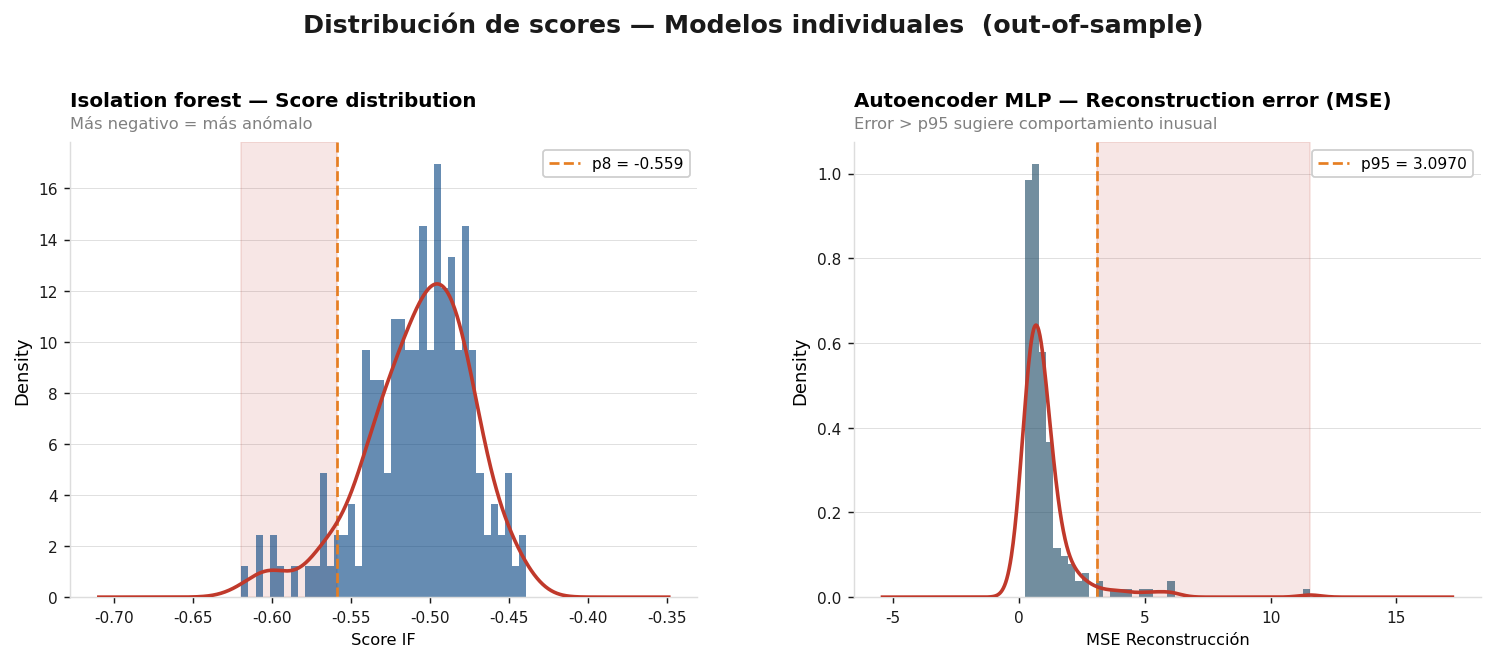

In [76]:
# CELDA 13
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 6.1 Distribución de scores individuales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("white")

fig.suptitle("Distribución de scores — Modelos individuales  (out-of-sample)",
             fontsize=14, fontweight="bold", color=P["text"], y=1.05)

valid_if = if_scores[~np.isnan(if_scores)]
valid_ae = ae_errors[~np.isnan(ae_errors)]

# Panel izquierdo: IForest
ax = axes[0]
ax.hist(valid_if, bins=40, color=P["primary"], alpha=0.6, density=True, zorder=2)
pd.Series(valid_if).plot.kde(ax=ax, color=P["secondary"], lw=2, zorder=3)

pct_umbral = np.percentile(valid_if, CONTAMINATION * 100)
ax.axvline(pct_umbral, color=P["accent"], lw=1.5, ls="--",
           label=f"p{CONTAMINATION*100:.0f} = {pct_umbral:.3f}")

ax.axvspan(valid_if.min(), pct_umbral, ymin=0, ymax=1,
           alpha=0.12, color=P["secondary"], zorder=1)

estilo_economist(ax)
ax.text(0.0, 1.08, "Isolation forest — Score distribution", transform=ax.transAxes, fontsize=11, fontweight="bold")
ax.text(0.0, 1.03, "Más negativo = más anómalo", transform=ax.transAxes, fontsize=9, color="gray")

ax.set_xlabel("Score IF", fontsize=9)

# Leyenda enmarcada
ax.legend(fontsize=8.5, loc="upper right", 
          frameon=True, framealpha=0.95, edgecolor="#cccccc", fancybox=True)

# Panel derecho: Autoencoder MLP
ax2 = axes[1]
ax2.hist(valid_ae, bins=40, color="#154360", alpha=0.6, density=True, zorder=2)
pd.Series(valid_ae).plot.kde(ax=ax2, color=P["secondary"], lw=2, zorder=3)

p95_ae = np.percentile(valid_ae, 95)
ax2.axvline(p95_ae, color=P["accent"], lw=1.5, ls="--",
            label=f"p95 = {p95_ae:.4f}")

ax2.axvspan(p95_ae, valid_ae.max(), ymin=0, ymax=1,
            alpha=0.12, color=P["secondary"], zorder=1)

estilo_economist(ax2)
ax2.text(0.0, 1.08, "Autoencoder MLP — Reconstruction error (MSE)", transform=ax2.transAxes, fontsize=11, fontweight="bold")
ax2.text(0.0, 1.03, "Error > p95 sugiere comportamiento inusual", transform=ax2.transAxes, fontsize=9, color="gray")

ax2.set_xlabel("MSE Reconstrucción", fontsize=9)

# Leyenda enmarcada
ax2.legend(fontsize=8.5, loc="upper right", 
           frameon=True, framealpha=0.95, edgecolor="#cccccc", fancybox=True)

fig.subplots_adjust(top=0.85, bottom=0.15, wspace=0.25)

os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(os.path.join(OUTPUT_DIR, "05_distribucion_scores.png"),
            dpi=180, bbox_inches="tight")
plt.show()

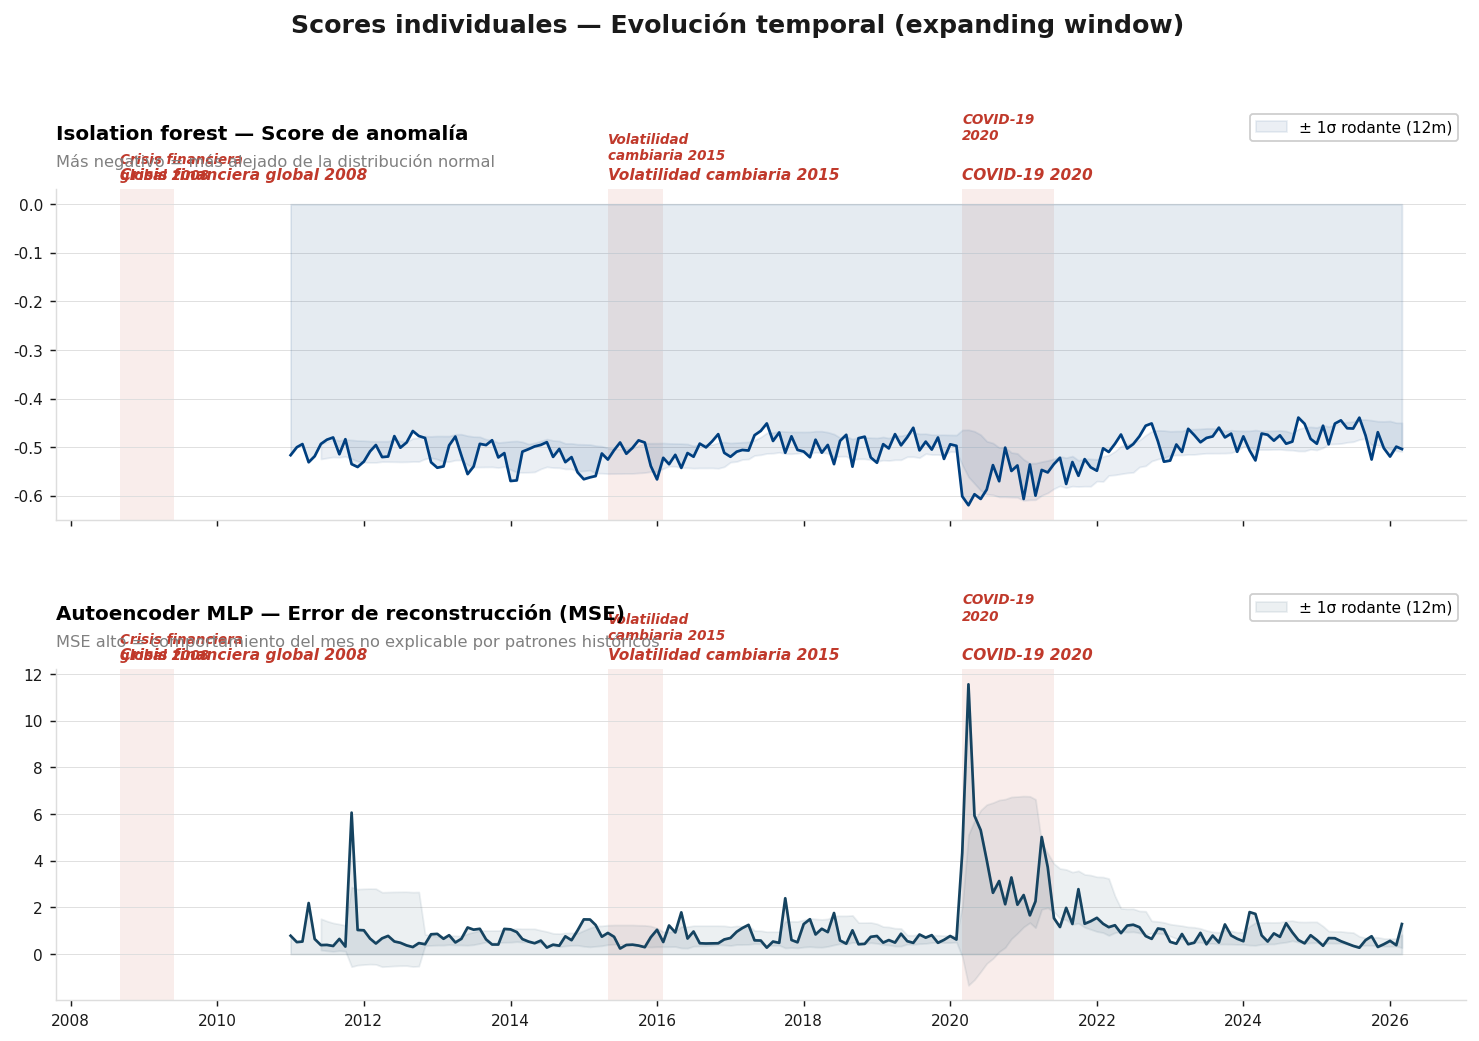

In [77]:
# CELDA 14
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# 6.2 Evolución temporal de scores individuales
idx = feats.index
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.patch.set_facecolor("white")

fig.suptitle("Scores individuales — Evolución temporal (expanding window)",
             fontsize=14, fontweight="bold", color=P["text"], y=1.05)

for ax, arr, title, subtitle, col in [
    (axes[0], if_scores,
     "Isolation forest — Score de anomalía",
     "Más negativo = más alejado de la distribución normal",
     P["primary"]),
    (axes[1], ae_errors,
     "Autoencoder MLP — Error de reconstrucción (MSE)",
     "MSE alto = comportamiento del mes no explicable por patrones históricos",
     "#154360"),
]:
    valid_mask = ~np.isnan(arr)
    ax.plot(idx[valid_mask], arr[valid_mask], color=col, lw=1.5, zorder=3)
    ax.fill_between(idx[valid_mask], arr[valid_mask], alpha=0.10, color=col)

    s_arr     = pd.Series(arr, index=idx)
    roll_std  = s_arr.rolling(12, min_periods=6).std()
    roll_mean = s_arr.rolling(12, min_periods=6).mean()
    ax.fill_between(idx,
                    roll_mean - roll_std,
                    roll_mean + roll_std,
                    alpha=0.08, color=col, label="± 1σ rodante (12m)")

    sombrear_crisis(ax, idx)

    trans_ax = ax.get_xaxis_transform()
    for nombre, (ini, _) in CRISIS_EPISODES.items():
        t0 = pd.Timestamp(ini)
        if t0 >= idx[0]:
            t0_float = float(mdates.date2num(t0))
            ax.text(t0_float, 1.02, nombre.replace("\n", " "),
                    fontsize=8.5, color=P["secondary"], va="bottom", ha="left",
                    style="italic", fontweight="bold", clip_on=False, transform=trans_ax)

    estilo_economist(ax)
    ax.text(0.0, 1.15, title, transform=ax.transAxes, fontsize=11, fontweight="bold")
    ax.text(0.0, 1.07, subtitle, transform=ax.transAxes, fontsize=9, color="gray")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    
    ax.legend(fontsize=8.5, loc="upper right", bbox_to_anchor=(1.0, 1.25),
              frameon=True, framealpha=0.95, edgecolor="#cccccc", fancybox=True)

fig.subplots_adjust(top=0.88, hspace=0.45, bottom=0.1)

os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(os.path.join(OUTPUT_DIR, "06_scores_temporales.png"),
            dpi=180, bbox_inches="tight")
plt.show()

In [78]:
# CELDA 15
def construir_señal_ews(
    feats: pd.DataFrame,
    if_scores: np.ndarray,
    ae_errors: np.ndarray,
) -> pd.DataFrame:
    idx = feats.index
 
    def minmax(v: np.ndarray) -> np.ndarray:
        vmin, vmax = np.nanmin(v), np.nanmax(v)
        return (v - vmin) / (vmax - vmin + 1e-9)
 
    if_norm = minmax(-if_scores)
    ae_norm = minmax(ae_errors)
 
    # Score compuesto y suavizado EWMA
    score_raw  = W_IF * if_norm + W_AE * ae_norm
    score_ewma = pd.Series(score_raw, index=idx).ewm(span=EWMA_SPAN).mean()
 
    # Umbral adaptativo rolling 36m
    roll_mean = score_ewma.rolling(36, min_periods=24).mean()
    roll_std  = score_ewma.rolling(36, min_periods=24).std()
    umbral    = roll_mean + UMBRAL_SIGMA * roll_std
    umbral_hi = roll_mean + (UMBRAL_SIGMA + 0.5) * roll_std
    umbral_lo = roll_mean + (UMBRAL_SIGMA - 0.5) * roll_std
 
    # Alerta con persistencia mínima
    alerta_cruda = (score_ewma > umbral).astype(int)
    alerta = (
        alerta_cruda
        .rolling(ALERTA_PERSIST, min_periods=ALERTA_PERSIST)
        .sum()
        .ge(ALERTA_PERSIST)
        .astype(int)
    )
 
    # Intensidad de alerta (4 niveles: 0-3)
    percentiles = np.nanpercentile(score_ewma.dropna(), [70, 85, 95])
    nivel = pd.cut(
        score_ewma,
        bins=[-np.inf, percentiles[0], percentiles[1], percentiles[2], np.inf],
        labels=[0, 1, 2, 3],
    ).astype(float)
 
    ews = pd.DataFrame({
        "IF_Score_Raw"  : if_scores,
        "IF_Score_Norm" : if_norm,
        "AE_Error_Raw"  : ae_errors,
        "AE_Error_Norm" : ae_norm,
        "Score_Raw"     : score_raw,
        "EWS_Score"     : score_ewma,
        "EWS_Umbral"    : umbral,
        "EWS_Umbral_Hi" : umbral_hi,
        "EWS_Umbral_Lo" : umbral_lo,
        "Alerta"        : alerta,
        "Nivel_Alerta"  : nivel,
    }, index=idx)
 
    n_alertas = int(alerta.sum())
    print("Señal EWS construida")
    print(f"Meses en alerta : {n_alertas} ({n_alertas / len(alerta):.1%} del período)")
    if n_alertas > 0:
        ma = alerta[alerta == 1].index
        print(f"Primera alerta  : {ma[0].strftime('%Y-%m')}")
        print(f"Última alerta   : {ma[-1].strftime('%Y-%m')}")
    print(f"Umbral σ        : {UMBRAL_SIGMA} | EWMA span: {EWMA_SPAN} | "
          f"Persistencia: {ALERTA_PERSIST}m")
    return ews
 
 
ews = construir_señal_ews(feats, if_scores, ae_errors)
ews.to_csv(os.path.join(OUTPUT_DIR, "señal_ews.csv"))
display(
    ews.describe().T.style
    .background_gradient(cmap="Blues")
    .format("{:.4f}")
    .set_caption("Estadísticos de la señal EWS")
)

Señal EWS construida
Meses en alerta : 9 (3.7% del período)
Primera alerta  : 2013-07
Última alerta   : 2020-08
Umbral σ        : 1.5 | EWMA span: 3 | Persistencia: 2m


,count,mean,std,min,25%,50%,75%,max
IF_Score_Raw,183.0000,-0.5076,0.0342,-0.6194,-0.5264,-0.5028,-0.4841,-0.4390
IF_Score_Norm,183.0000,0.3799,0.1897,0.0000,0.2496,0.3533,0.4842,1.0000
AE_Error_Raw,183.0000,1.0848,1.2387,0.2384,0.4939,0.7392,1.1459,11.5630
AE_Error_Norm,183.0000,0.0747,0.1094,0.0000,0.0226,0.0442,0.0801,1.0000
Score_Raw,183.0000,0.3188,0.1666,0.0014,0.2045,0.2990,0.3978,1.0000
EWS_Score,183.0000,0.3190,0.1385,0.0489,0.2278,0.2975,0.3807,0.8078
EWS_Umbral,160.0000,0.4987,0.1321,0.2926,0.4173,0.4810,0.5927,0.7417
EWS_Umbral_Hi,160.0000,0.5537,0.1537,0.3267,0.4546,0.5264,0.6771,0.8348
EWS_Umbral_Lo,160.0000,0.4436,0.1109,0.2585,0.3777,0.4346,0.5084,0.6490
Alerta,243.0000,0.0370,0.1892,0.0000,0.0000,0.0000,0.0000,1.0000


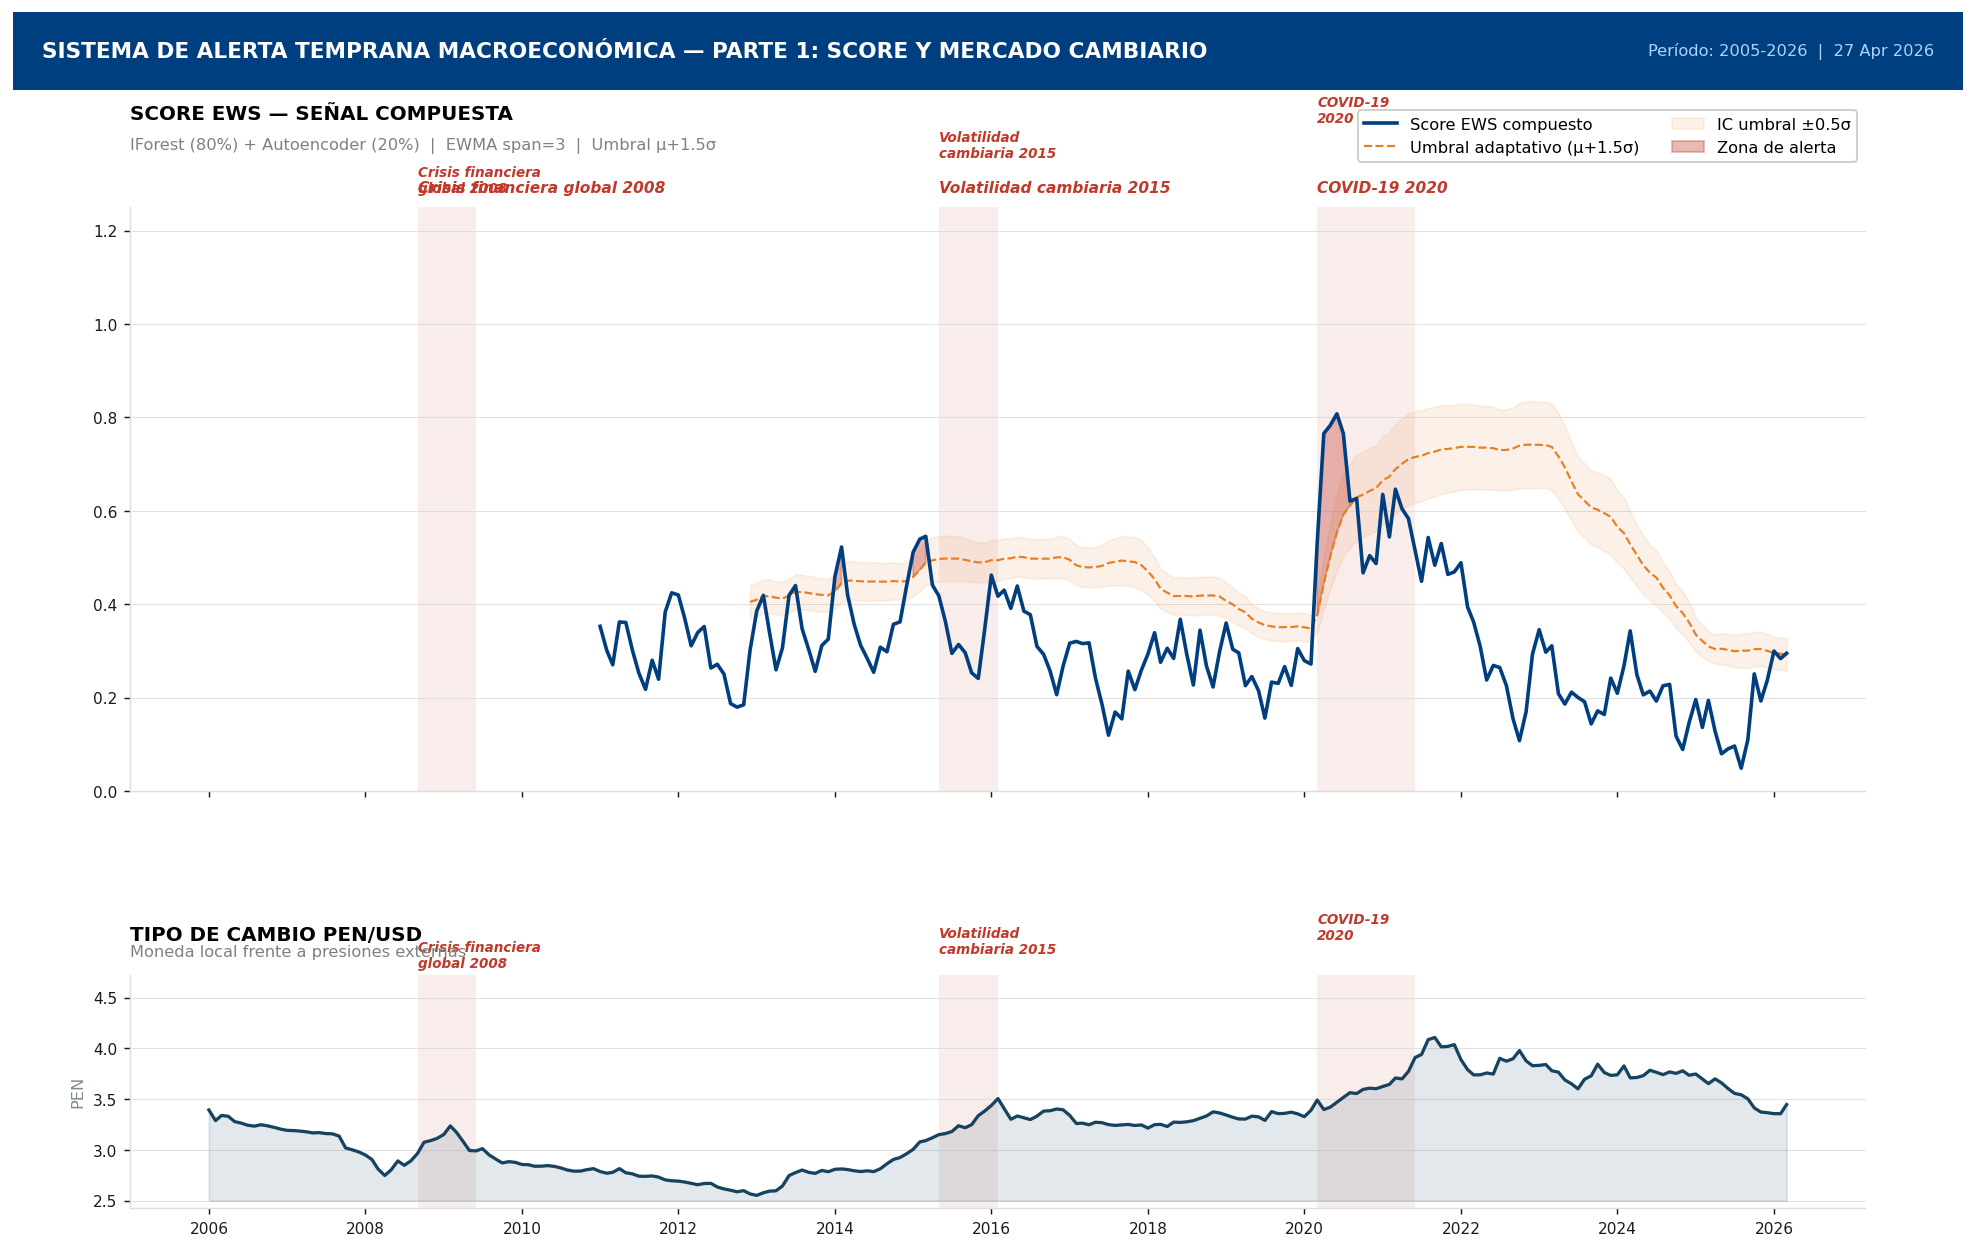

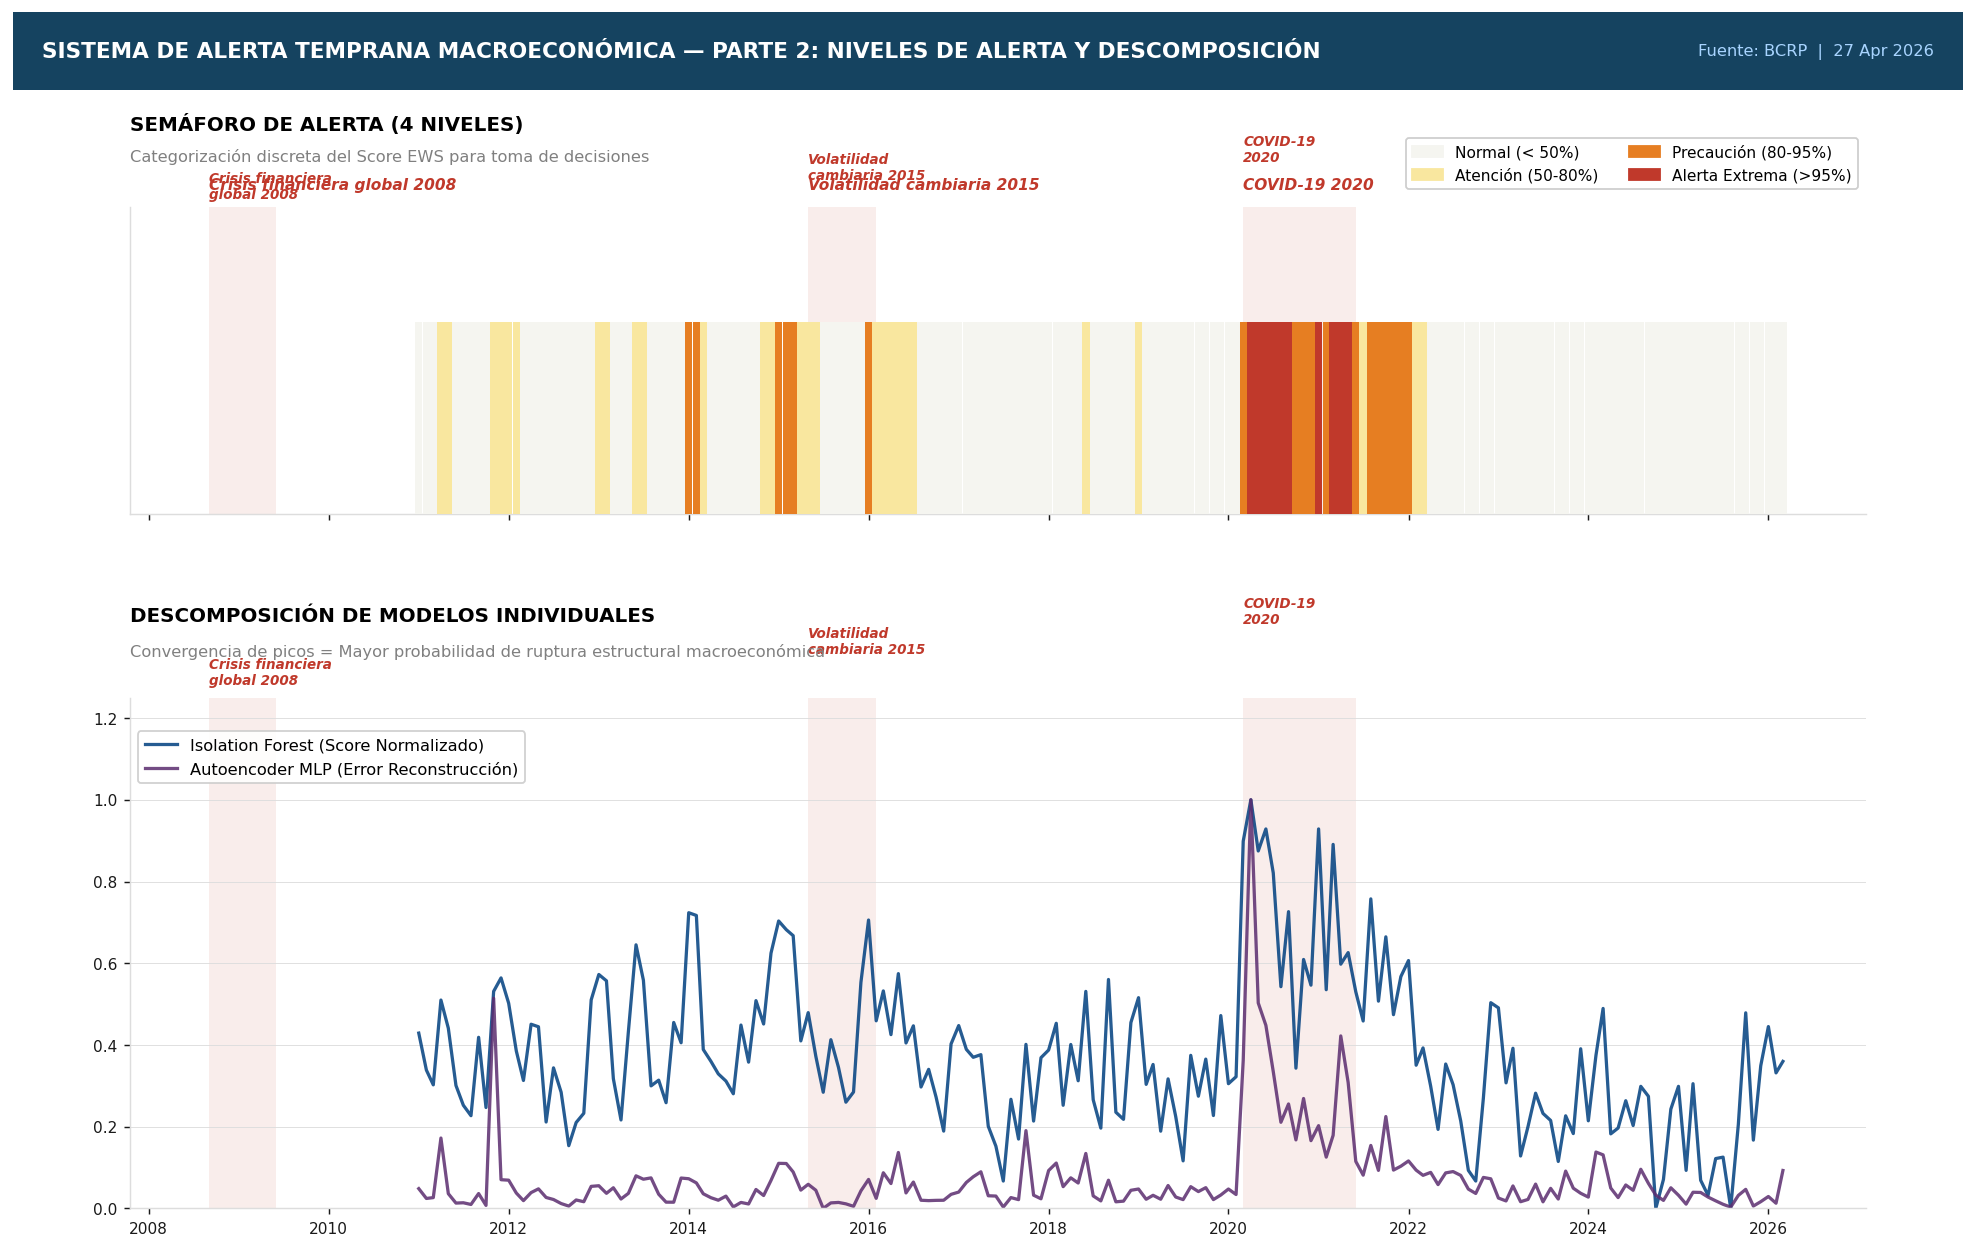

In [79]:
# CELDA 16
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from datetime import datetime

idx = ews.index

# FIGURA 1: SCORE COMPUESTO Y TIPO DE CAMBIO
fig1 = plt.figure(figsize=(15, 10))
fig1.patch.set_facecolor("white")

rect1 = mpatches.FancyBboxPatch(
    (0, 0.94), 1, 0.06, transform=fig1.transFigure,
    boxstyle="square,pad=0", linewidth=0, facecolor=P["primary"]
)
fig1.patches.append(rect1)
fig1.text(0.015, 0.97,
         "SISTEMA DE ALERTA TEMPRANA MACROECONÓMICA — PARTE 1: SCORE Y MERCADO CAMBIARIO",
         color="white", fontsize=12, fontweight="bold", transform=fig1.transFigure, va="center")
fig1.text(0.985, 0.97,
         f"Período: 2005-2026  |  {datetime.now().strftime('%d %b %Y')}",
         color="#a8d4ff", fontsize=9, transform=fig1.transFigure, va="center", ha="right")

gs1 = gridspec.GridSpec(2, 1, figure=fig1, hspace=0.45, height_ratios=[3.0, 1.2])
ax_score = fig1.add_subplot(gs1[0])
ax_tc    = fig1.add_subplot(gs1[1], sharex=ax_score)

# Panel A: Score EWS
ax_score.plot(idx, ews["EWS_Score"], color=P["primary"], lw=2.0, label="Score EWS compuesto", zorder=4)
ax_score.plot(idx, ews["EWS_Umbral"], color=P["accent"], lw=1.2, ls="--", label=f"Umbral adaptativo (μ+{UMBRAL_SIGMA}σ)", zorder=3)
ax_score.fill_between(idx, ews["EWS_Umbral_Lo"], ews["EWS_Umbral_Hi"], alpha=0.10, color=P["accent"], label="IC umbral ±0.5σ")
ax_score.fill_between(idx, ews["EWS_Score"], ews["EWS_Umbral"],
                      where=(ews["EWS_Score"] > ews["EWS_Umbral"]),  # pyright: ignore
                      color=P["secondary"], alpha=0.35, label="Zona de alerta", zorder=2)
sombrear_crisis(ax_score, idx)

trans_score = ax_score.get_xaxis_transform()
for nombre, (ini, _) in CRISIS_EPISODES.items():
    t0 = pd.Timestamp(ini)
    if t0 >= idx[0]:
        t0_float = float(mdates.date2num(t0))
        ax_score.text(t0_float, 1.02, nombre.replace("\n", " "),
                      fontsize=8.5, color=P["secondary"], va="bottom", ha="left",
                      style="italic", fontweight="bold", clip_on=False, transform=trans_score)

estilo_economist(ax_score) 
ax_score.text(0.0, 1.15, "SCORE EWS — SEÑAL COMPUESTA", transform=ax_score.transAxes, fontsize=11, fontweight="bold")
ax_score.text(0.0, 1.10, f"IForest ({W_IF:.0%}) + Autoencoder ({W_AE:.0%})  |  EWMA span={EWMA_SPAN}  |  Umbral μ+{UMBRAL_SIGMA}σ", transform=ax_score.transAxes, fontsize=9, color="gray")

ax_score.set_ylim(0, 1.25)
ax_score.set_ylabel(" ", fontsize=9)
ax_score.legend(fontsize=9, loc="upper right", bbox_to_anchor=(1.0, 1.18),
                frameon=True, framealpha=1, ncol=2, edgecolor="#cccccc")

# Panel B: Tipo de cambio
if "Tipo_Cambio_PEN" in df_raw.columns:
    tc = df_raw["Tipo_Cambio_PEN"].reindex(idx)
    ax_tc.plot(idx, tc, color="#154360", lw=1.8, zorder=3)
    ax_tc.fill_between(idx, tc, tc.min() * 0.98, alpha=0.12, color="#154360")
    sombrear_crisis(ax_tc, idx)
    
    estilo_economist(ax_tc)
    ax_tc.text(0.0, 1.15, "TIPO DE CAMBIO PEN/USD", transform=ax_tc.transAxes, fontsize=11, fontweight="bold")
    ax_tc.text(0.0, 1.08, "Moneda local frente a presiones externas", transform=ax_tc.transAxes, fontsize=9, color="gray")
    
    ax_tc.set_ylabel("PEN", fontsize=9, color=P["neutral"])
    ax_tc.set_ylim(tc.min() * 0.95, tc.max() * 1.15)

ax_tc.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_tc.xaxis.set_major_locator(mdates.YearLocator(2))
plt.setp(ax_score.get_xticklabels(), visible=False)

fig1.align_ylabels([ax_score, ax_tc]) 
fig1.subplots_adjust(top=0.85, bottom=0.08, left=0.06, right=0.95)

os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(os.path.join(OUTPUT_DIR, "07a_dashboard_parte1.png"), dpi=180, bbox_inches="tight")
plt.show()

# FIGURA 2: SEMÁFORO Y SCORES INDIVIDUALES
fig2 = plt.figure(figsize=(15, 10))
fig2.patch.set_facecolor("white")

rect2 = mpatches.FancyBboxPatch(
    (0, 0.94), 1, 0.06, transform=fig2.transFigure,
    boxstyle="square,pad=0", linewidth=0, facecolor="#154360"
)
fig2.patches.append(rect2)
fig2.text(0.015, 0.97,
         "SISTEMA DE ALERTA TEMPRANA MACROECONÓMICA — PARTE 2: NIVELES DE ALERTA Y DESCOMPOSICIÓN",
         color="white", fontsize=12, fontweight="bold", transform=fig2.transFigure, va="center")
fig2.text(0.985, 0.97,
         f"Fuente: BCRP  |  {datetime.now().strftime('%d %b %Y')}",
         color="#a8d4ff", fontsize=9, transform=fig2.transFigure, va="center", ha="right")

gs2 = gridspec.GridSpec(2, 1, figure=fig2, hspace=0.45, height_ratios=[1.2, 2.0])
ax_alert = fig2.add_subplot(gs2[0])
ax_sub   = fig2.add_subplot(gs2[1], sharex=ax_alert)

# Panel C: Semáforo
_NIVEL_COLORES = [P["bg"], "#f9e79f", P["accent"], P["secondary"]]
for t, val in ews["Nivel_Alerta"].items():
    if np.isnan(val):
        continue
    ax_alert.bar(t, 1, width=30, color=_NIVEL_COLORES[int(val)], align="center", zorder=3, lw=0)  # pyright: ignore

sombrear_crisis(ax_alert, idx)

trans_alert = ax_alert.get_xaxis_transform()
for nombre, (ini, _) in CRISIS_EPISODES.items():
    t0 = pd.Timestamp(ini)
    if t0 >= idx[0]:
        t0_float = float(mdates.date2num(t0))
        ax_alert.text(t0_float, 1.05, nombre.replace("\n", " "),
                      fontsize=8.5, color=P["secondary"], va="bottom", ha="left",
                      style="italic", fontweight="bold", clip_on=False, transform=trans_alert)

ax_alert.set_ylim(0, 1.6)
ax_alert.set_yticks([])
ax_alert.set_ylabel(" ", fontsize=8, labelpad=6)

estilo_economist(ax_alert)
ax_alert.text(0.0, 1.25, "SEMÁFORO DE ALERTA (4 NIVELES)", transform=ax_alert.transAxes, fontsize=11, fontweight="bold")
ax_alert.text(0.0, 1.15, "Categorización discreta del Score EWS para toma de decisiones", transform=ax_alert.transAxes, fontsize=9, color="gray")

leyenda_semaforo = [
    mpatches.Patch(color=P["bg"], label="Normal (< 50%)"),
    mpatches.Patch(color="#f9e79f", label="Atención (50-80%)"),
    mpatches.Patch(color=P["accent"], label="Precaución (80-95%)"),
    mpatches.Patch(color=P["secondary"], label="Alerta Extrema (>95%)")
]
ax_alert.legend(handles=leyenda_semaforo, fontsize=8.5,
                loc="upper right", bbox_to_anchor=(1.0, 1.25),
                frameon=True, ncol=2, framealpha=0.95, edgecolor="#cccccc")

# Panel D: Scores individuales
ax_sub.plot(idx, ews["IF_Score_Norm"], color=P["primary"], lw=1.8, alpha=0.85, label="Isolation Forest (Score Normalizado)")
ax_sub.plot(idx, ews["AE_Error_Norm"], color="#5b2c6f", lw=1.8, alpha=0.85, label="Autoencoder MLP (Error Reconstrucción)")
sombrear_crisis(ax_sub, idx)

# Estilo y Textos alineados
estilo_economist(ax_sub)
ax_sub.text(0.0, 1.15, "DESCOMPOSICIÓN DE MODELOS INDIVIDUALES", transform=ax_sub.transAxes, fontsize=11, fontweight="bold")
ax_sub.text(0.0, 1.08, "Convergencia de picos = Mayor probabilidad de ruptura estructural macroeconómica", transform=ax_sub.transAxes, fontsize=9, color="gray")

ax_sub.set_ylim(0, 1.25)
ax_sub.set_ylabel(" ", fontsize=9)
ax_sub.legend(fontsize=9, frameon=True, framealpha=0.9,
              loc="upper left", bbox_to_anchor=(0.0, 0.95))

ax_sub.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_sub.xaxis.set_major_locator(mdates.YearLocator(2))
plt.setp(ax_alert.get_xticklabels(), visible=False)

fig2.align_ylabels([ax_alert, ax_sub]) 
fig2.subplots_adjust(top=0.85, bottom=0.08, left=0.06, right=0.95)
plt.savefig(os.path.join(OUTPUT_DIR, "07b_dashboard_parte2.png"), dpi=180, bbox_inches="tight")
plt.show()

In [80]:
# CELDA 17
def backtesting(ews: pd.DataFrame) -> pd.DataFrame:
    
    rows: list[dict] = []
    for nombre, (ini_str, fin_str) in CRISIS_EPISODES.items():
        inicio = pd.Timestamp(ini_str)
        fin    = pd.Timestamp(fin_str)
        ventana_ini = inicio - pd.DateOffset(months=HORIZONTE_EWS)
 
        ventana_pre   = ews.loc[ventana_ini:inicio, "Alerta"]
        alertas_pre   = ventana_pre.sum()
        alertas_idx   = ventana_pre[ventana_pre == 1].index
        primera_alerta = alertas_idx[0] if len(alertas_idx) > 0 else None
        lead_time = (
            (inicio - primera_alerta).days // 30
            if primera_alerta is not None else None
        )
        score_pre_max = ews.loc[ventana_ini:inicio, "EWS_Score"].max()
 
        rows.append({
            "Episodio"        : nombre.replace("\n", " "),
            "Inicio"          : inicio.strftime("%Y-%m"),
            "Fin"             : fin.strftime("%Y-%m"),
            "Meses_Crisis"    : (fin - inicio).days // 30,
            "Detectado"       : alertas_pre > 0,
            "Alertas_Pre"     : int(alertas_pre),
            "Primera_Alerta"  : primera_alerta.strftime("%Y-%m") if primera_alerta else "—",
            "Lead_Time_Meses" : lead_time if lead_time is not None else 0,
            "Dentro_Horizonte": (lead_time or 0) >= HORIZONTE_EWS,
            "Score_Max_Prev"  : round(float(score_pre_max), 4),
        })
        icono = "✓" if alertas_pre > 0 else "✗"
        lt    = f"{lead_time}m antes" if lead_time else "No detectado"
        print(f"  {icono} {nombre.replace(chr(10), ' '):35s} | {lt:20s} "
              f"| Score_max={score_pre_max:.3f}")
 
    return pd.DataFrame(rows)
 
print("BACKTESTING — EPISODIOS HISTÓRICOS")
print("=" * 65)
bt_df = backtesting(ews)
 
display(HTML("<h4 style='color:#003f7f'>Resultados de backtesting</h4>"))
 
def color_detectado(val) -> str:
    if val is True:  return "background-color:#d5f5e3; font-weight:bold; color:#1e8449"
    if val is False: return "background-color:#fadbd8; font-weight:bold; color:#c0392b"
    return ""
 
display(
    bt_df.style
    .map(color_detectado, subset=["Detectado", "Dentro_Horizonte"])  # FIX: .map()
    .background_gradient(subset=["Lead_Time_Meses", "Score_Max_Prev"], cmap="YlGn")
    .format({"Score_Max_Prev": "{:.4f}"})
    .set_caption(f"Horizonte mínimo aceptable: {HORIZONTE_EWS} meses")
)

BACKTESTING — EPISODIOS HISTÓRICOS
  ✗ Crisis financiera global 2008       | No detectado         | Score_max=nan
  ✓ Volatilidad cambiaria 2015          | 2m antes             | Score_max=0.546
  ✗ COVID-19 2020                       | No detectado         | Score_max=0.532


,Episodio,Inicio,Fin,Meses_Crisis,Detectado,Alertas_Pre,Primera_Alerta,Lead_Time_Meses,Dentro_Horizonte,Score_Max_Prev
0,Crisis financiera global 2008,2008-09,2009-06,9,False,0,—,0,False,nan
1,Volatilidad cambiaria 2015,2015-05,2016-02,9,True,2,2015-02,2,False,0.5456
2,COVID-19 2020,2020-03,2021-06,15,False,0,—,0,False,0.5316


In [81]:
# CELDA 18
y_true = pd.Series(0, index=ews.index, name="Crisis_Label")
for _, (ini_str, _) in CRISIS_EPISODES.items():
    inicio = pd.Timestamp(ini_str)
    ventana_ini = inicio - pd.DateOffset(months=HORIZONTE_EWS)
    y_true.loc[ventana_ini:inicio] = 1

mask_valid = ~ews["EWS_Score"].isna()

y_t = np.asarray(y_true[mask_valid], dtype=int)
y_s = np.asarray(ews.loc[mask_valid, "EWS_Score"], dtype=float)
y_a = np.asarray(ews.loc[mask_valid, "Alerta"], dtype=int)

roc_auc = roc_auc_score(y_t, y_s)
prec    = precision_score(y_t, y_a, zero_division=0)
rec     = recall_score(y_t, y_a, zero_division=0)
f1      = f1_score(y_t, y_a, zero_division=0)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(y_t.reshape(-1, 1), y_t)
f1_base = f1_score(y_t, dummy.predict(y_t.reshape(-1, 1)), zero_division=0)

metricas = pd.DataFrame({
    "Métrica"   : ["ROC-AUC", "Precision", "Recall", "F1-Score", "F1 Baseline"],
    "EWS"       : [roc_auc, prec, rec, f1, "—"],
    "Baseline"  : ["0.500", "—", "—", f"{f1_base:.4f}", f"{f1_base:.4f}"],
    "Benchmark" : ["≥0.70", "≥0.50", "≥0.60", "≥0.55", "Referencia"],
})

display(HTML("<h4 style='color:#003f7f'>Métricas de clasificación EWS</h4>"))


def color_metric(val) -> str:
    try:
        v = float(val)
        if   v >= 0.70: return "background:#d5f5e3; font-weight:bold; color:#1e8449"
        elif v >= 0.50: return "background:#fef9e7; font-weight:bold; color:#9a7d0a"
        else:           return "background:#fadbd8; color:#c0392b"
    except (TypeError, ValueError):
        return ""

display(
    metricas.style
    .map(color_metric, subset=["EWS"])
    .set_caption(
        f"Etiquetas: meses en ventana pre-crisis ({HORIZONTE_EWS}m antes del inicio)"
    )
)
print(f"\n  ROC-AUC : {roc_auc:.4f}  |  F1: {f1:.4f}  "
      f"|  Precision: {prec:.4f}  |  Recall: {rec:.4f}")

,Métrica,EWS,Baseline,Benchmark
0,ROC-AUC,0.665258,0.500,≥0.70
1,Precision,0.222222,—,≥0.50
2,Recall,0.142857,—,≥0.60
3,F1-Score,0.173913,0.0000,≥0.55
4,F1 Baseline,—,0.0000,Referencia



  ROC-AUC : 0.6653  |  F1: 0.1739  |  Precision: 0.2222  |  Recall: 0.1429


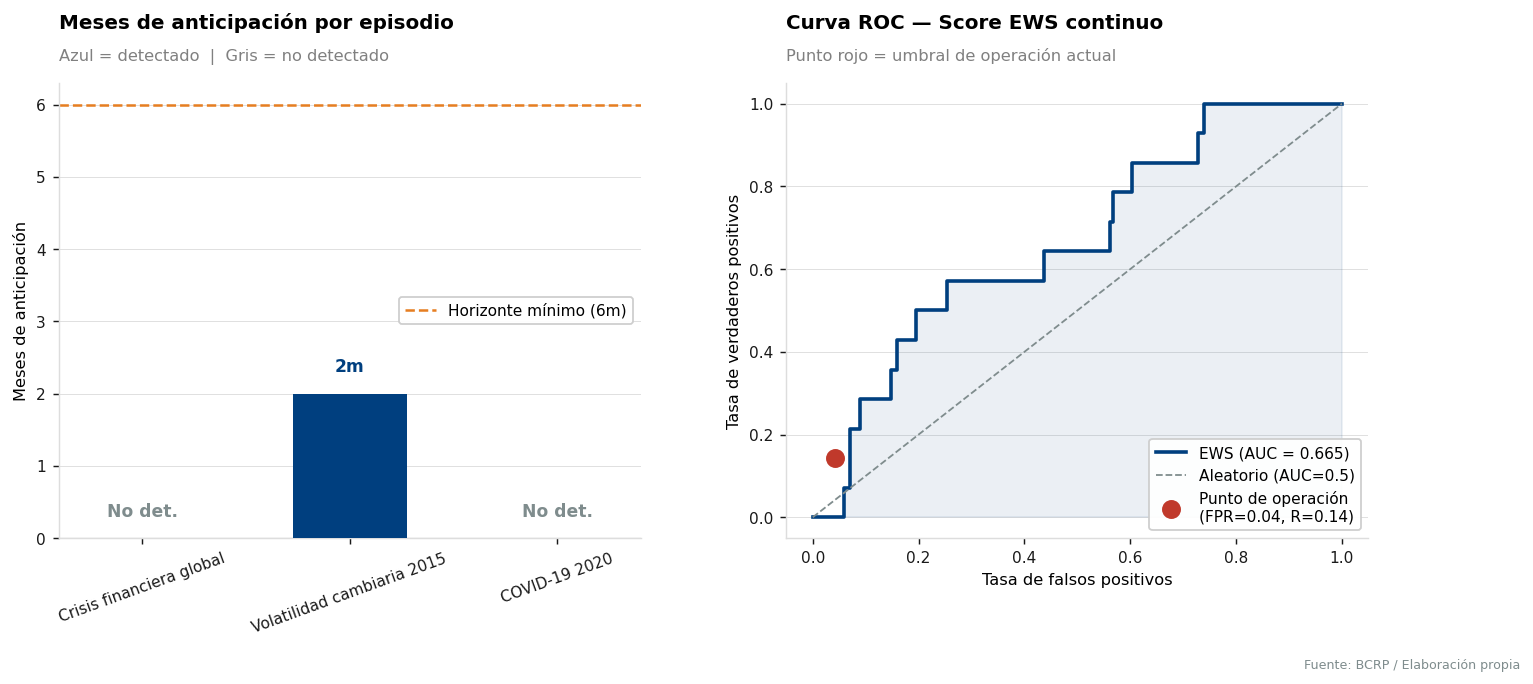

In [82]:
# CELDA 19
from sklearn.metrics import roc_curve, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("white")

# Panel izquierdo: Lead-time por episodio
ax = axes[0]
nombres_cortos = bt_df["Episodio"].str.split().str[:3].str.join(" ")
leads      = bt_df["Lead_Time_Meses"].values
colores_bt = [P["primary"] if d else P["neutral"] for d in bt_df["Detectado"]]

bars = ax.bar(nombres_cortos, leads, color=colores_bt, zorder=3, width=0.55)

ax.axhline(HORIZONTE_EWS, color=P["accent"], ls="--", lw=1.4,
           label=f"Horizonte mínimo ({HORIZONTE_EWS}m)")
ax.axhline(0, color=P["grid"], lw=0.8)

for bar, lead, det in zip(bars, leads, bt_df["Detectado"]):
    label = f"{lead}m" if det else "No det."
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            label, ha="center", fontsize=9.5, fontweight="bold",
            color=P["primary"] if det else P["neutral"])

estilo_economist(ax)
ax.text(0.0, 1.12, "Meses de anticipación por episodio", transform=ax.transAxes, fontsize=11, fontweight="bold")
ax.text(0.0, 1.05, "Azul = detectado  |  Gris = no detectado", transform=ax.transAxes, fontsize=9, color="gray")

ax.set_ylabel("Meses de anticipación", fontsize=9)
ax.tick_params(axis="x", labelrotation=20)

ax.legend(fontsize=8.5, loc="center right", 
          frameon=True, framealpha=0.95, edgecolor="#cccccc", fancybox=True)

# Panel derecho: Curva ROC
ax2 = axes[1]
fpr, tpr, _ = roc_curve(y_t, y_s)

ax2.plot(fpr, tpr, color=P["primary"], lw=2, label=f"EWS (AUC = {roc_auc:.3f})")
ax2.plot([0, 1], [0, 1], color=P["neutral"], ls="--", lw=1, label="Aleatorio (AUC=0.5)")
ax2.fill_between(fpr, tpr, alpha=0.08, color=P["primary"])

tn, fp, fn, tp = confusion_matrix(y_t, y_a).ravel()
fpr_operacion = fp / (fp + tn)

ax2.scatter([fpr_operacion], [rec], color=P["secondary"], s=90, zorder=5,
            label=f"Punto de operación\n(FPR={fpr_operacion:.2f}, R={rec:.2f})")

estilo_economist(ax2)
ax2.text(0.0, 1.12, "Curva ROC — Score EWS continuo", transform=ax2.transAxes, fontsize=11, fontweight="bold")
ax2.text(0.0, 1.05, "Punto rojo = umbral de operación actual", transform=ax2.transAxes, fontsize=9, color="gray")

ax2.set_xlabel("Tasa de falsos positivos", fontsize=9)
ax2.set_ylabel("Tasa de verdaderos positivos", fontsize=9)

ax2.legend(fontsize=8.5, loc="lower right", 
           frameon=True, framealpha=0.95, edgecolor="#cccccc", fancybox=True)

fig.text(0.99, -0.05, "Fuente: BCRP / Elaboración propia",
         ha="right", fontsize=7, color=P["neutral"])

fig.subplots_adjust(top=0.85, bottom=0.15, wspace=0.25)

plt.savefig(os.path.join(OUTPUT_DIR, "08_backtesting_roc.png"), dpi=180, bbox_inches="tight")
plt.show()

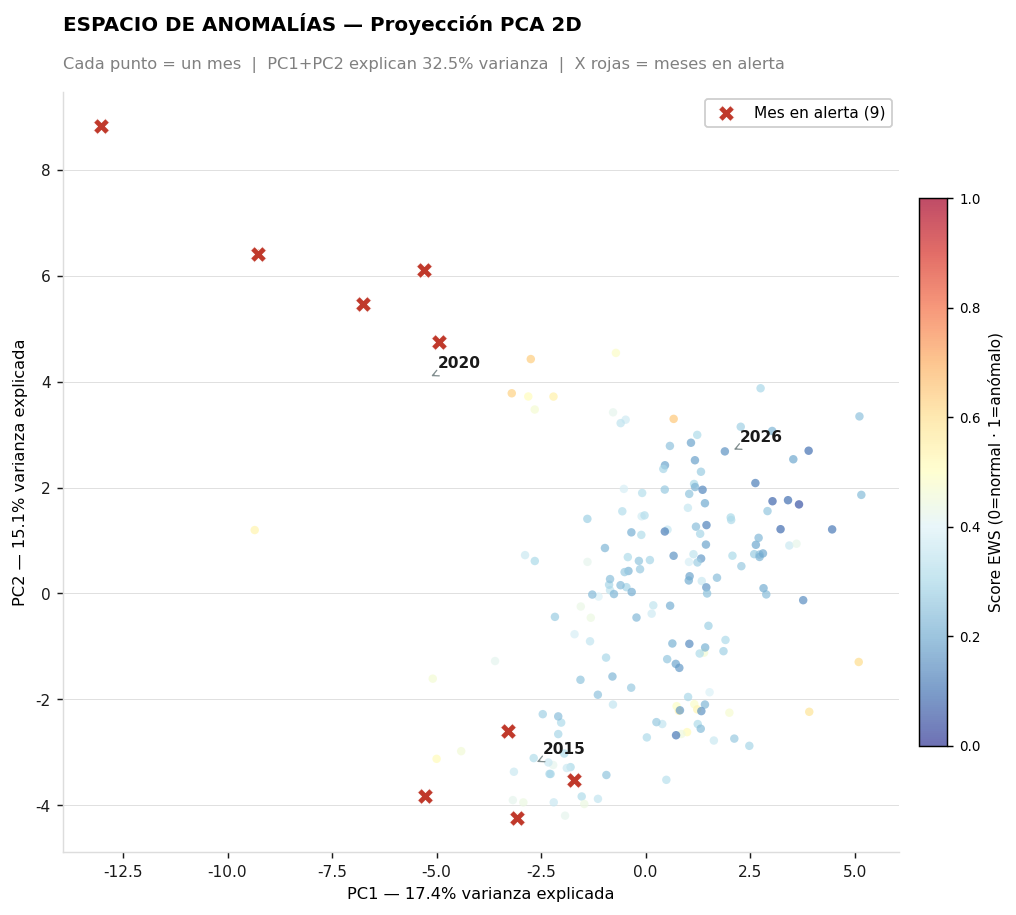

Varianza explicada: PC1=17.4% | PC2=15.1% | Acum.=32.5%


In [83]:
# CELDA 20
from sklearn.decomposition import PCA

# 10.1 PCA 2D — espacio de anomalías
mask_v    = ~np.isnan(X_oos_sc).any(axis=1)
X_v       = X_oos_sc[mask_v]
idx_v     = feats.index[mask_v]  # pyright: ignore

scores_v  = np.asarray(ews.loc[idx_v, "EWS_Score"], dtype=float)
alertas_v = np.asarray(ews.loc[idx_v, "Alerta"], dtype=int)
years_v   = idx_v.year

pca = PCA(n_components=2, random_state=42)
X2d     = pca.fit_transform(X_v)
var_exp = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 7.5))
fig.patch.set_facecolor("white")

sc = ax.scatter(X2d[:, 0], X2d[:, 1], c=scores_v, cmap="RdYlBu_r",
                vmin=0, vmax=1, alpha=0.70, s=22, zorder=3, linewidths=0)

ax.scatter(X2d[alertas_v == 1, 0], X2d[alertas_v == 1, 1],
           c=P["secondary"], marker="X", s=75, zorder=6,
           label=f"Mes en alerta ({int(alertas_v.sum())})",
           linewidths=0.4, edgecolors="white")

for yr in [2008, 2015, 2020, 2005, 2026]:
    mask_yr = years_v == yr
    if mask_yr.any():
        cx, cy = X2d[mask_yr, 0].mean(), X2d[mask_yr, 1].mean()
        ax.annotate(str(yr), (cx, cy),
                    fontsize=8.5, color=P["text"], fontweight="bold",
                    arrowprops=dict(arrowstyle="->", color=P["neutral"], lw=0.7),
                    xytext=(cx + 0.15, cy + 0.15))

cbar = plt.colorbar(sc, ax=ax, shrink=0.72, pad=0.02)
cbar.set_label("Score EWS (0=normal · 1=anómalo)", fontsize=8.5)
cbar.ax.tick_params(labelsize=7.5)

ax.set_xlabel(f"PC1 — {var_exp[0]:.1%} varianza explicada", fontsize=9)
ax.set_ylabel(f"PC2 — {var_exp[1]:.1%} varianza explicada", fontsize=9)

estilo_economist(ax)
ax.text(0.0, 1.08, "ESPACIO DE ANOMALÍAS — Proyección PCA 2D", transform=ax.transAxes, fontsize=11, fontweight="bold")
ax.text(0.0, 1.03, f"Cada punto = un mes  |  PC1+PC2 explican {sum(var_exp):.1%} varianza  |  X rojas = meses en alerta", transform=ax.transAxes, fontsize=9, color="gray")

ax.legend(fontsize=8.5, loc="upper right", 
          frameon=True, framealpha=0.95, edgecolor="#cccccc", fancybox=True)

fig.subplots_adjust(top=0.88, bottom=0.1)

import os
plt.savefig(os.path.join(OUTPUT_DIR, "09_pca_anomaly_space.png"),
            dpi=180, bbox_inches="tight")
plt.show()

print(f"Varianza explicada: PC1={var_exp[0]:.1%} | PC2={var_exp[1]:.1%} "
      f"| Acum.={sum(var_exp):.1%}")

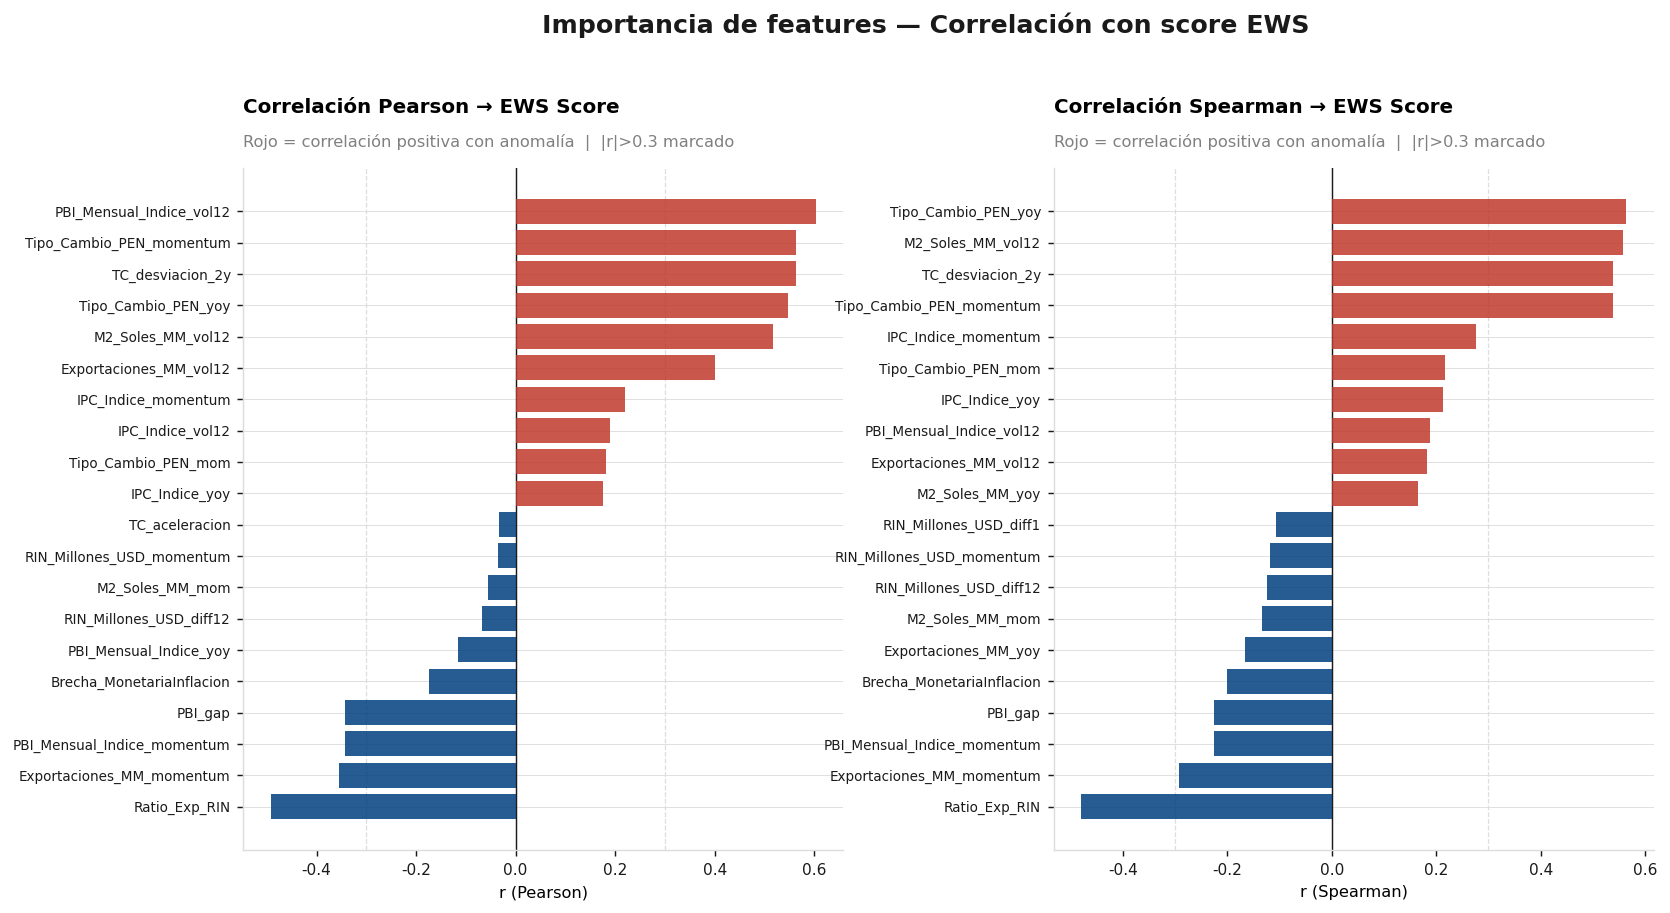

,Pearson_r,Spearman_r,Abs_Pearson
PBI_Mensual_Indice_vol12,0.6038,0.1886,0.6038
TC_desviacion_2y,0.5637,0.5388,0.5637
Tipo_Cambio_PEN_momentum,0.5637,0.5388,0.5637
Tipo_Cambio_PEN_yoy,0.5472,0.5644,0.5472
M2_Soles_MM_vol12,0.5172,0.5584,0.5172
Ratio_Exp_RIN,-0.4923,-0.4803,0.4923
Exportaciones_MM_vol12,0.4009,0.1822,0.4009
Exportaciones_MM_momentum,-0.3545,-0.2923,0.3545
PBI_Mensual_Indice_momentum,-0.3424,-0.2256,0.3424
PBI_gap,-0.3424,-0.2256,0.3424


In [84]:
# CELDA 21
from IPython.display import display, HTML

# 10.2 Importancia de features (correlación con score EWS)
corr_pearson  = feats.corrwith(ews["EWS_Score"], method="pearson").sort_values()
corr_spearman = feats.corrwith(ews["EWS_Score"], method="spearman").sort_values()

n_show = min(20, len(corr_pearson))
half   = n_show // 2

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor("white")

fig.suptitle("Importancia de features — Correlación con score EWS",
             fontsize=14, fontweight="bold", color=P["text"], y=1.02)

for ax, corr_data, method in [
    (axes[0], pd.concat([corr_pearson.head(half), corr_pearson.tail(half)]).sort_values(), "Pearson"),
    (axes[1], pd.concat([corr_spearman.head(half), corr_spearman.tail(half)]).sort_values(), "Spearman"),
]:
    colores_bar = [P["secondary"] if v > 0 else P["primary"] for v in corr_data.values]
    
    ax.barh(corr_data.index, corr_data.values, color=colores_bar, zorder=3, alpha=0.85)
    ax.axvline(0,    color=P["text"], lw=0.8)
    ax.axvline( 0.3, color=P["grid"], lw=0.7, ls="--")
    ax.axvline(-0.3, color=P["grid"], lw=0.7, ls="--")
    
    estilo_economist(ax)
    
    ax.text(0.0, 1.08, f"Correlación {method} → EWS Score", transform=ax.transAxes, fontsize=11, fontweight="bold")
    ax.text(0.0, 1.03, "Rojo = correlación positiva con anomalía  |  |r|>0.3 marcado", transform=ax.transAxes, fontsize=9, color="gray")
    
    ax.set_xlabel(f"r ({method})", fontsize=9)
    ax.tick_params(axis="y", labelsize=7.5)

fig.subplots_adjust(top=0.85, bottom=0.1, wspace=0.35)

plt.savefig(os.path.join(OUTPUT_DIR, "10_importancia_features.png"),
            dpi=180, bbox_inches="tight")
plt.show()

ranking = pd.DataFrame({
    "Pearson_r"  : corr_pearson,
    "Spearman_r" : corr_spearman,
    "Abs_Pearson": corr_pearson.abs(),
}).sort_values("Abs_Pearson", ascending=False)

display(HTML("<h4 style='color:#003f7f'>Top 10 Features más correlacionados con EWS Score</h4>"))
display(
    ranking.head(10).style
    .background_gradient(subset=["Abs_Pearson"], cmap="YlOrRd")
    .format("{:.4f}")
)

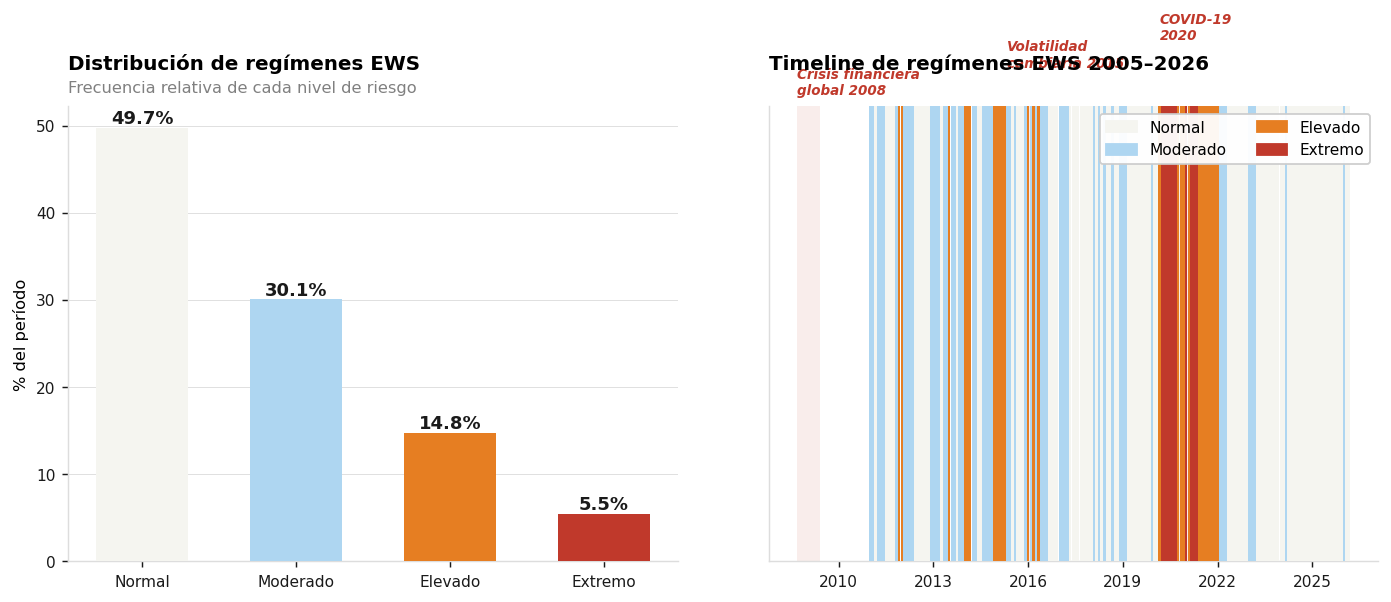

Régimen,Umbral_Inferior,N_Meses,Pct_%
Normal,0.000000,91,49.730000
Moderado,0.297500,55,30.050000
Elevado,0.419600,27,14.750000
Extremo,0.579600,10,5.460000


In [85]:
# CELDA 22
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import os
from IPython.display import display

# 10.3 Análisis de regímenes
score_valid = ews["EWS_Score"].dropna()
p50, p80, p95 = score_valid.quantile([0.50, 0.80, 0.95])

LABELS_REGIMEN = ["Normal", "Moderado", "Elevado", "Extremo"]
COLORES_REGIMEN = [P["bg"], "#aed6f1", P["accent"], P["secondary"]]

def asignar_regimen(v: float) -> float:
    if np.isnan(v): return np.nan
    if v < p50:     return 0.0
    if v < p80:     return 1.0
    if v < p95:     return 2.0
    return 3.0

ews["Regimen"] = ews["EWS_Score"].apply(asignar_regimen)
freq_regimen   = ews["Regimen"].value_counts().sort_index()
freq_pct       = freq_regimen / freq_regimen.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("white")

# Panel izquierdo: Distribución de regímenes
ax = axes[0]
bars = ax.bar(
    [LABELS_REGIMEN[int(i)] for i in freq_pct.index],
    freq_pct.values, color=COLORES_REGIMEN, zorder=3, width=0.6,
)

for bar, pct in zip(bars, freq_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5, f"{pct:.1f}%",
            ha="center", fontsize=10, fontweight="bold", color=P["text"])

estilo_economist(ax)
ax.text(0.0, 1.08, "Distribución de regímenes EWS", transform=ax.transAxes, fontsize=11, fontweight="bold")
ax.text(0.0, 1.03, "Frecuencia relativa de cada nivel de riesgo", transform=ax.transAxes, fontsize=9, color="gray")

ax.set_ylabel("% del período", fontsize=9)

# Panel derecho: Timeline de regímenes
ax2 = axes[1]
for t, reg in ews["Regimen"].items():
    if np.isnan(reg):
        continue
    ax2.bar(t, 1, width=30, color=COLORES_REGIMEN[int(reg)],
            align="center", zorder=3, lw=0)

sombrear_crisis(ax2, ews.index)
ax2.set_ylim(0, 1)
ax2.set_yticks([])

handles = [mpatches.Patch(color=col, label=lbl) for lbl, col in zip(LABELS_REGIMEN, COLORES_REGIMEN)]

ax2.legend(handles=handles, fontsize=8.5, loc="upper right", 
           frameon=True, framealpha=0.95, edgecolor="#cccccc", fancybox=True, ncol=2)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator(3))

estilo_economist(ax2)
ax2.text(0.0, 1.08, "Timeline de regímenes EWS 2005–2026", transform=ax2.transAxes, fontsize=11, fontweight="bold")

# Usamos subplots_adjust para proteger los títulos en lugar de tight_layout
fig.subplots_adjust(top=0.85, bottom=0.15, wspace=0.15)

plt.savefig(os.path.join(OUTPUT_DIR, "11_regimenes_ews.png"), dpi=180, bbox_inches="tight")
plt.show()

reg_summary = pd.DataFrame({
    "Régimen"         : LABELS_REGIMEN,
    "Umbral_Inferior" : [0, round(p50, 4), round(p80, 4), round(p95, 4)],
    "N_Meses"         : [int(freq_regimen.get(i, 0)) for i in range(4)],
    "Pct_%"           : [round(freq_pct.get(i, 0), 2) for i in range(4)],
})

def pintar_filas(row):
    colores = {
        "Normal": P["bg"],
        "Moderado": "#aed6f1",
        "Elevado": P["accent"],
        "Extremo": P["secondary"]
    }
    
    bg = colores.get(row["Régimen"], "white")
    txt = "white" if row["Régimen"] == "Extremo" else "black"
    
    return [f"background-color: {bg}; color: {txt}; font-weight: bold"] * len(row)

display(reg_summary.style.apply(pintar_filas, axis=1).hide(axis="index"))

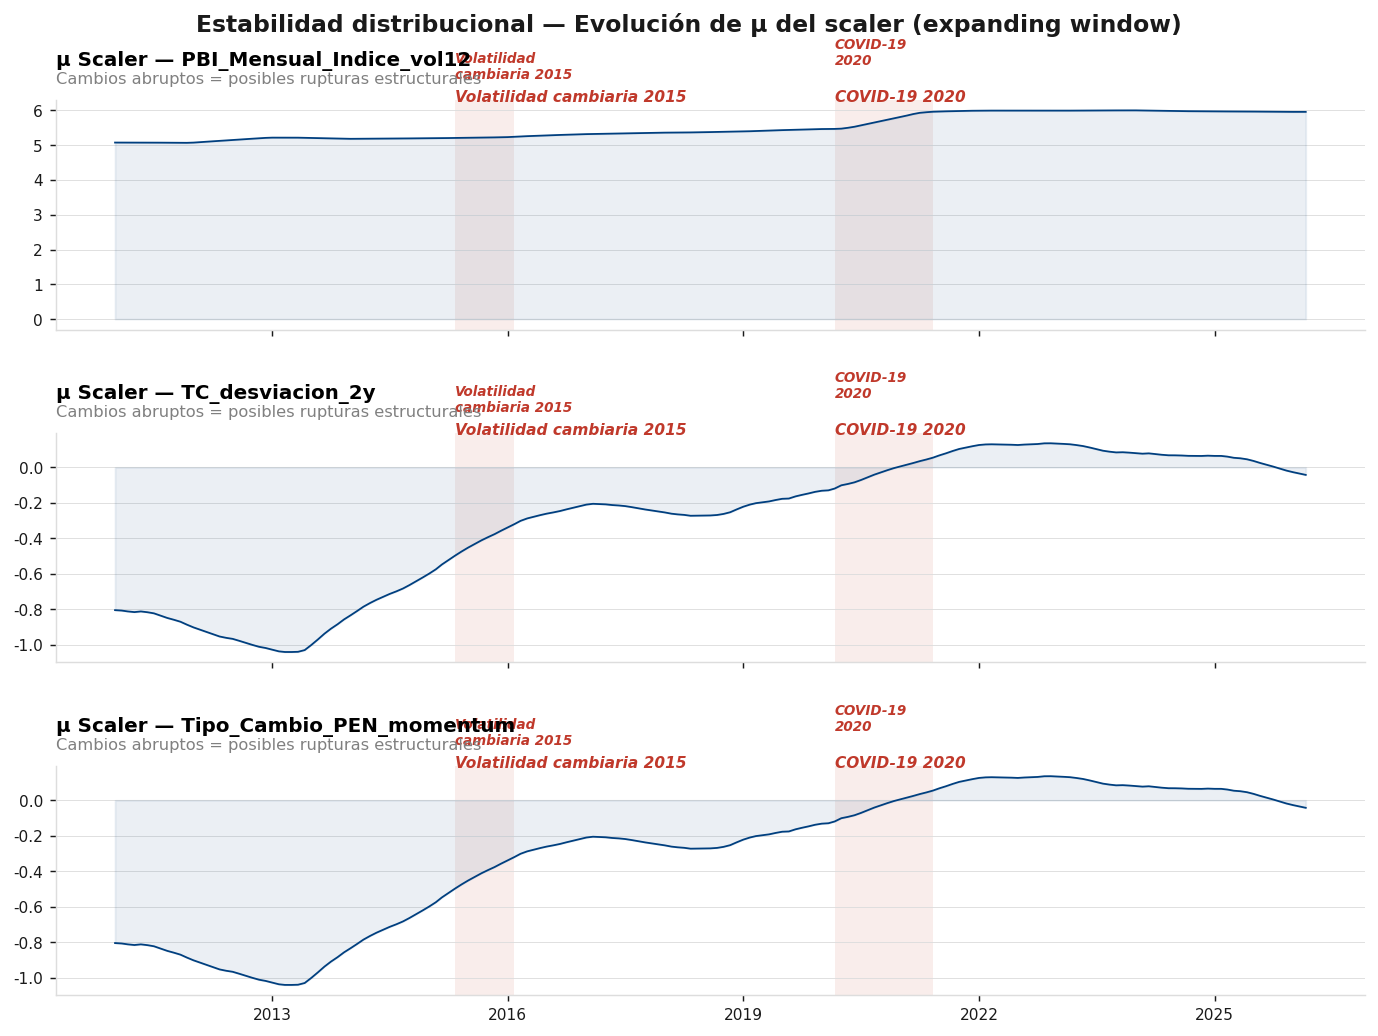

In [86]:
# CELDA 23
# 10.4 Estabilidad distribucional — evolución de μ del scaler
feat_names = feats.columns.tolist()
top3_idx   = [feat_names.index(f) for f in ranking.index[:3] if f in feat_names]

if len(top3_idx) >= 2:
    mask_sc = ~np.isnan(scaler_means).any(axis=1)
    sc_idx  = feats.index[mask_sc]  # pyright: ignore
    sc_vals = scaler_means[mask_sc]

    fig, axes_sc = plt.subplots(len(top3_idx), 1,                            
                                figsize=(13, 2.8 * len(top3_idx)), sharex=True)
    fig.patch.set_facecolor("white")

    fig.suptitle(
        "Estabilidad distribucional — Evolución de μ del scaler (expanding window)",
        fontsize=13, fontweight="bold", color=P["text"], y=1.00
    )

    axes_list = [axes_sc] if len(top3_idx) == 1 else list(axes_sc)
    
    for ax, fi in zip(axes_list, top3_idx):
        feat_n = feat_names[fi]
        ax.plot(sc_idx, sc_vals[:, fi], color=P["primary"], lw=1, zorder=3)
        ax.fill_between(sc_idx, sc_vals[:, fi], alpha=0.08, color=P["primary"])
        sombrear_crisis(ax, sc_idx)
        
        trans_ax = ax.get_xaxis_transform()
        for nombre, (ini, _) in CRISIS_EPISODES.items():
            t0 = pd.Timestamp(ini)
            if t0 >= sc_idx[0]:
                t0_float = float(mdates.date2num(t0))
                # y=1.02 coloca el texto justo rozando el borde superior del gráfico
                ax.text(t0_float, 0.98, nombre.replace("\n", " "),
                        fontsize=8.5, color=P["secondary"], va="bottom", ha="left",
                        style="italic", fontweight="bold", clip_on=False, transform=trans_ax)
                
        estilo_economist(ax)
        ax.text(0.0, 1.15, f"μ Scaler — {feat_n}", transform=ax.transAxes, fontsize=11, fontweight="bold")
        ax.text(0.0, 1.07, "Cambios abruptos = posibles rupturas estructurales", transform=ax.transAxes, fontsize=9, color="gray")
        
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.xaxis.set_major_locator(mdates.YearLocator(3))

    fig.subplots_adjust(top=0.92, hspace=0.45, bottom=0.1)
    
    plt.savefig(os.path.join(OUTPUT_DIR, "12_estabilidad_scaler.png"),
                dpi=180, bbox_inches="tight")
    plt.show()

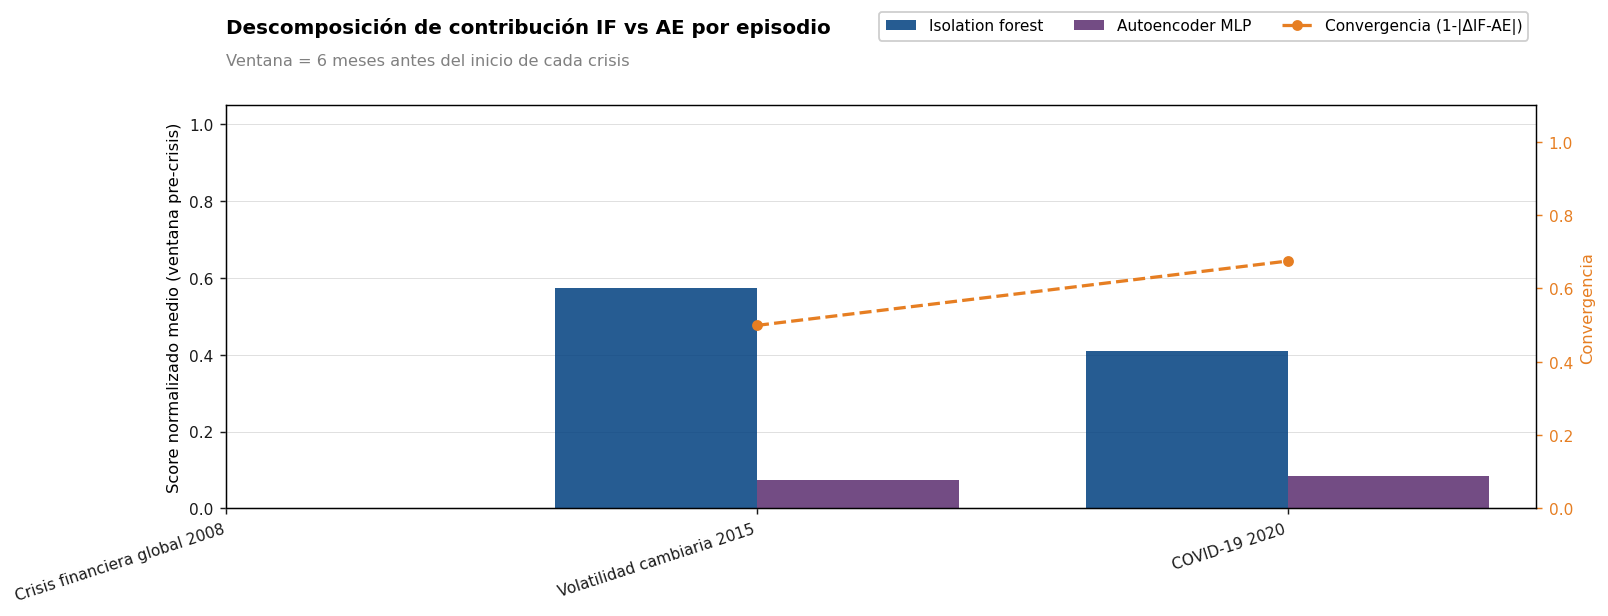

,IF_Contrib,AE_Contrib,Score_Medio,Convergencia
Episodio,,,,
Crisis financiera global 2008,nan,nan,nan,nan
Volatilidad cambiaria 2015,0.5740,0.0732,0.4651,0.4992
COVID-19 2020,0.4093,0.0842,0.3016,0.6749


In [87]:
# CELDA 24 — Descomposición IF vs AE por período de alerta
contrib_rows: list[dict] = []
for nombre, (ini_str, _) in CRISIS_EPISODES.items():
    inicio      = pd.Timestamp(ini_str)
    ventana_ini = inicio - pd.DateOffset(months=HORIZONTE_EWS)
    w = ews.loc[ventana_ini:inicio]
    if w.empty:
        continue
    contrib_rows.append({
        "Episodio"     : nombre.replace("\n", " "),
        "IF_Contrib"   : w["IF_Score_Norm"].mean(),
        "AE_Contrib"   : w["AE_Error_Norm"].mean(),
        "Score_Medio"  : w["EWS_Score"].mean(),
        "Convergencia" : 1 - abs(w["IF_Score_Norm"].mean() - w["AE_Error_Norm"].mean()),
    })

contrib_df = pd.DataFrame(contrib_rows).set_index("Episodio")

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor("white")

x      = np.arange(len(contrib_df))
width  = 0.38
bars_if = ax.bar(x - width / 2, contrib_df["IF_Contrib"],
                 width, label="Isolation forest", color=P["primary"], alpha=0.85, zorder=3)
bars_ae = ax.bar(x + width / 2, contrib_df["AE_Contrib"],
                 width, label="Autoencoder MLP",  color="#5b2c6f",   alpha=0.85, zorder=3)

ax2_conv = ax.twinx()
ax2_conv.plot(x, contrib_df["Convergencia"], color=P["accent"],
              lw=1.8, ls="--", marker="o", ms=5, zorder=4,
              label="Convergencia (1-|ΔIF-AE|)")
ax2_conv.set_ylim(0, 1.1)
ax2_conv.set_ylabel("Convergencia", fontsize=9, color=P["accent"])
ax2_conv.tick_params(axis="y", colors=P["accent"], labelsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(contrib_df.index, rotation=18, ha="right", fontsize=9)
ax.set_ylabel("Score normalizado medio (ventana pre-crisis)", fontsize=9)
ax.set_ylim(0, 1.05) # Un poco más de espacio superior

estilo_economist(ax)
ax.text(0.0, 1.18, "Descomposición de contribución IF vs AE por episodio", transform=ax.transAxes, fontsize=11, fontweight="bold")
ax.text(0.0, 1.10, f"Ventana = {HORIZONTE_EWS} meses antes del inicio de cada crisis", transform=ax.transAxes, fontsize=9, color="gray")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_conv.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8.5, 
          loc="upper right", bbox_to_anchor=(1.0, 1.25), 
          frameon=True, framealpha=0.95, edgecolor="#cccccc", fancybox=True, ncol=3)

fig.subplots_adjust(top=0.82, bottom=0.2)

plt.savefig(os.path.join(OUTPUT_DIR, "13_descomposicion_modelos.png"),
            dpi=180, bbox_inches="tight")
plt.show()
    
display(HTML("<h4 style='color:#003f7f'>Contribución por Modelo — Ventana Pre-Crisis</h4>"))
display(
    contrib_df.style
    .background_gradient(subset=["IF_Contrib", "AE_Contrib", "Convergencia"], cmap="Blues")
    .format("{:.4f}")
    .set_caption("Convergencia alta = ambos modelos detectaron la anomalía")
)

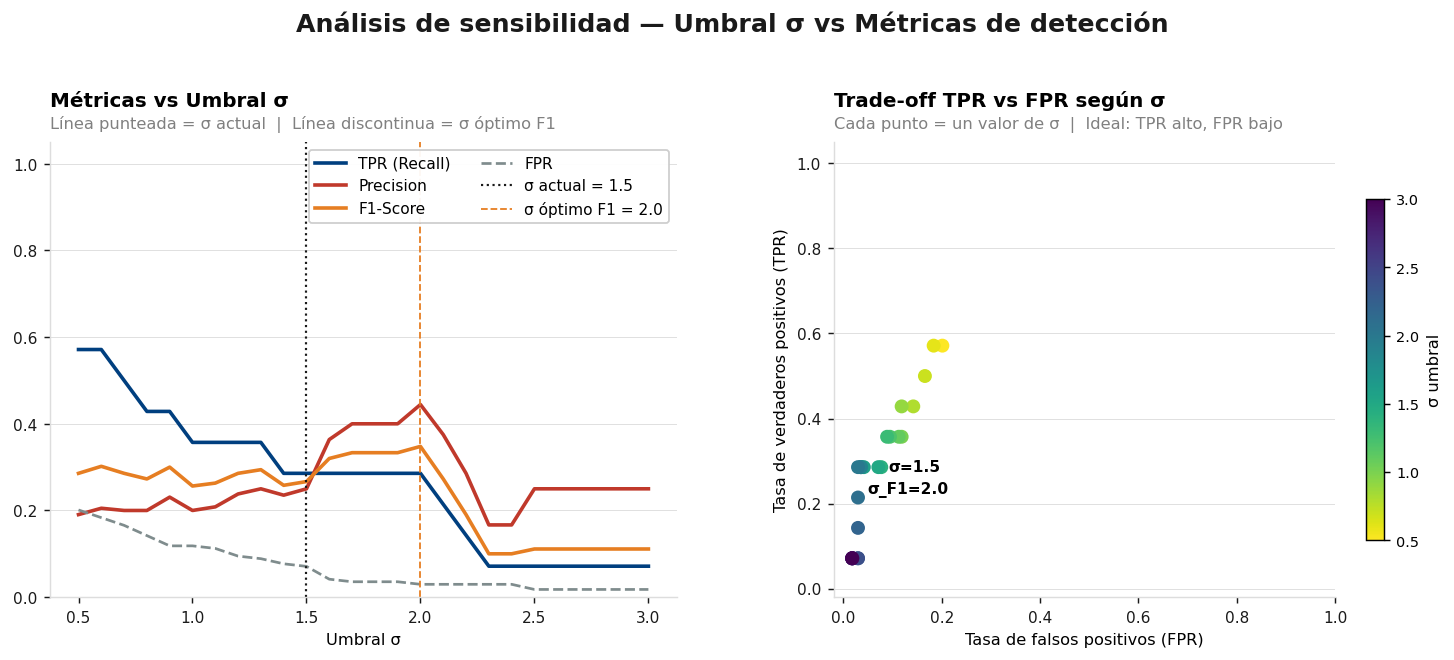

 σ óptimo (F1 máximo): 2.0  →  F1=0.3478  |  σ actual: 1.5  →  F1=0.2667


In [88]:
# CELDA 25 — Análisis de sensibilidad del umbral σ
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import precision_score, recall_score, f1_score

sigma_vals  = np.arange(0.5, 3.05, 0.1)
sens_rows: list[dict] = []

roll_mean_base = ews["EWS_Score"].rolling(36, min_periods=24).mean()
roll_std_base  = ews["EWS_Score"].rolling(36, min_periods=24).std()
mask_v2 = ~ews["EWS_Score"].isna()

for sigma in sigma_vals:
    umbral_s = roll_mean_base + float(sigma) * roll_std_base
    alerta_s = (ews["EWS_Score"] > umbral_s).astype(int)
    
    y_a_s    = np.asarray(alerta_s[mask_v2], dtype=int)
    
    _prec = precision_score(y_t, y_a_s, zero_division=0)
    _rec  = recall_score(y_t, y_a_s, zero_division=0)
    _f1   = f1_score(y_t, y_a_s, zero_division=0)
    _fpr  = float(((y_a_s == 1) & (y_t == 0)).sum() /
                  max((y_t == 0).sum(), 1))
    sens_rows.append({
        "Sigma"    : round(sigma, 2),
        "TPR"      : _rec,
        "FPR"      : _fpr,
        "Precision": _prec,
        "F1"       : _f1,
        "N_Alertas": int(y_a_s.sum()),
    })

sens_df = pd.DataFrame(sens_rows).set_index("Sigma")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("white")

fig.suptitle("Análisis de sensibilidad — Umbral σ vs Métricas de detección",
             fontsize=14, fontweight="bold", color=P["text"], y=1.05)

# Panel izquierdo: métricas vs sigma
ax = axes[0]
ax.plot(sens_df.index, sens_df["TPR"],       color=P["primary"],   lw=2, label="TPR (Recall)")
ax.plot(sens_df.index, sens_df["Precision"], color=P["secondary"], lw=2, label="Precision")
ax.plot(sens_df.index, sens_df["F1"],        color=P["accent"],    lw=2, label="F1-Score")
ax.plot(sens_df.index, sens_df["FPR"],       color=P["neutral"],   lw=1.5, ls="--", label="FPR")

ax.axvline(UMBRAL_SIGMA, color=P["text"], lw=1.2, ls=":",
           label=f"σ actual = {UMBRAL_SIGMA}")
idx_f1_max = sens_df["F1"].idxmax()
ax.axvline(idx_f1_max, color=P["accent"], lw=1, ls="--",
           label=f"σ óptimo F1 = {idx_f1_max:.1f}")

estilo_economist(ax)
ax.text(0.0, 1.08, "Métricas vs Umbral σ", transform=ax.transAxes, fontsize=11, fontweight="bold")
ax.text(0.0, 1.03, "Línea punteada = σ actual  |  Línea discontinua = σ óptimo F1", transform=ax.transAxes, fontsize=9, color="gray")

ax.set_xlabel("Umbral σ", fontsize=9)
ax.set_ylim(0, 1.05)

ax.legend(fontsize=8.5, loc="upper right", 
          frameon=True, framealpha=0.95, edgecolor="#cccccc", fancybox=True, ncol=2)

# Panel derecho: Trade-off TPR vs FPR (tipo ROC por umbral)
ax2 = axes[1]
sc_s = ax2.scatter(sens_df["FPR"], sens_df["TPR"],
                   c=sens_df.index, cmap="viridis_r", s=45, zorder=3)

estilo_economist(ax2)
ax2.text(0.0, 1.08, "Trade-off TPR vs FPR según σ", transform=ax2.transAxes, fontsize=11, fontweight="bold")
ax2.text(0.0, 1.03, "Cada punto = un valor de σ  |  Ideal: TPR alto, FPR bajo", transform=ax2.transAxes, fontsize=9, color="gray")

offset_y = 0
for sigma_mark, label_mark in [(UMBRAL_SIGMA, f"σ={UMBRAL_SIGMA}"),
                                (idx_f1_max,   f"σ_F1={idx_f1_max:.1f}")]:
    row = sens_df.loc[round(sigma_mark, 1)]
    ax2.annotate(label_mark, (row["FPR"], row["TPR"]),
                 fontsize=8.5, fontweight="bold", color="black",
                 xytext=(row["FPR"] + 0.02, row["TPR"] - 0.01 - offset_y))
    offset_y += 0.05 

cbar2 = plt.colorbar(sc_s, ax=ax2, shrink=0.75)
cbar2.set_label("σ umbral", fontsize=9)
cbar2.ax.tick_params(labelsize=8)

ax2.set_xlabel("Tasa de falsos positivos (FPR)", fontsize=9)
ax2.set_ylabel("Tasa de verdaderos positivos (TPR)", fontsize=9)
ax2.set_xlim(-0.02, 1.0)
ax2.set_ylim(-0.02, 1.05)

fig.subplots_adjust(top=0.85, bottom=0.15, wspace=0.25)

plt.savefig(os.path.join(OUTPUT_DIR, "14_sensibilidad_umbral.png"),
            dpi=180, bbox_inches="tight")
plt.show()

f1_opt = sens_df.loc[idx_f1_max, "F1"]
f1_actual = sens_df.loc[round(UMBRAL_SIGMA, 1), 'F1']  # pyright: ignore

print(f" σ óptimo (F1 máximo): {idx_f1_max:.1f}  →  F1={f1_opt:.4f}  "
      f"|  σ actual: {UMBRAL_SIGMA}  →  F1={f1_actual:.4f}")

,Inicio,Fin,Duración_Meses,Score_Max,Score_Medio,Mes_Pico,IF_Medio,AE_Medio
0,2013-07,2013-07,1,0.4400,0.4400,2013-07,0.5583,0.0713
1,2014-02,2014-02,1,0.5227,0.5227,2014-02,0.7169,0.0623
2,2015-02,2015-03,2,0.5456,0.5425,2015-03,0.6748,0.0994
3,2020-04,2020-08,5,0.8078,0.7487,2020-06,0.8334,0.4992


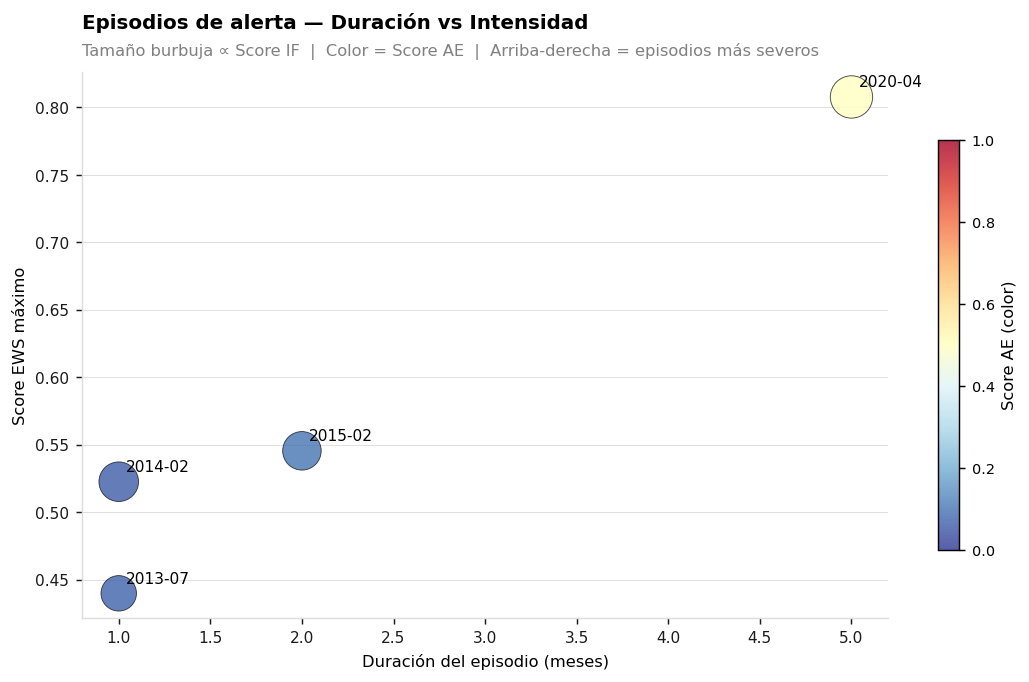

Episodios exportados exitosamente: 4


In [ ]:
# CELDA 26 — Episodios de alerta cronológicos
from IPython.display import display, HTML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

alerta_s  = ews["Alerta"].fillna(0).astype(int)
grupos     = (alerta_s.diff().fillna(0) != 0).cumsum()
episodios_alerta: list[dict] = []

for grupo_id, grupo_df in ews.groupby(grupos):
    if grupo_df["Alerta"].iloc[0] != 1:
        continue
    score_ep = grupo_df["EWS_Score"].dropna()
    if score_ep.empty:
        continue
        
    mes_pico_ts = pd.to_datetime(score_ep.idxmax())
        
    episodios_alerta.append({
        "Inicio"         : grupo_df.index[0].strftime("%Y-%m"),
        "Fin"            : grupo_df.index[-1].strftime("%Y-%m"),
        "Duración_Meses" : len(grupo_df),
        "Score_Max"      : round(float(score_ep.max()), 4),
        "Score_Medio"    : round(float(score_ep.mean()), 4),
        "Mes_Pico"       : mes_pico_ts.strftime("%Y-%m"),
        "IF_Medio"       : round(float(grupo_df["IF_Score_Norm"].mean()), 4),
        "AE_Medio"       : round(float(grupo_df["AE_Error_Norm"].mean()), 4),
    })

ep_df = pd.DataFrame(episodios_alerta) if episodios_alerta else pd.DataFrame()

if not ep_df.empty:
    display(HTML("<h4 style='color:#003f7f'>Episodios de alerta cronológicos</h4>"))
    display(
        ep_df.style
        .background_gradient(subset=["Score_Max", "Duración_Meses"], cmap="YlOrRd")
        .format({"Score_Max": "{:.4f}", "Score_Medio": "{:.4f}",
                 "IF_Medio": "{:.4f}", "AE_Medio": "{:.4f}"})
        .set_caption(f"Total de episodios de alerta: {len(ep_df)}")
    )

    # Gráfico: duración vs score máximo, burbujas = IF vs AE
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor("white")
    
    scatter = ax.scatter(
        ep_df["Duración_Meses"], ep_df["Score_Max"],
        c=ep_df["AE_Medio"], cmap="RdYlBu_r",
        s=ep_df["IF_Medio"] * 600 + 50,
        alpha=0.80, zorder=3, edgecolors=P["text"], linewidths=0.5,
        vmin=0, vmax=1,
    )
    
    for _, row in ep_df.iterrows():
        ax.annotate(row["Inicio"], (row["Duración_Meses"], row["Score_Max"]),
                    fontsize=8.5, ha="left", va="bottom",
                    xytext=(4, 4), textcoords="offset points")
                    
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.75)
    cbar.set_label("Score AE (color)", fontsize=9)
    cbar.ax.tick_params(labelsize=8)
    
    ax.set_xlabel("Duración del episodio (meses)", fontsize=9)
    ax.set_ylabel("Score EWS máximo", fontsize=9)
    
    estilo_economist(ax)
    ax.text(0.0, 1.08, "Episodios de alerta — Duración vs Intensidad", transform=ax.transAxes, fontsize=11, fontweight="bold")
    ax.text(0.0, 1.03, "Tamaño burbuja ∝ Score IF  |  Color = Score AE  |  Arriba-derecha = episodios más severos", transform=ax.transAxes, fontsize=9, color="gray")
    git add .
    fig.subplots_adjust(top=0.85, bottom=0.15)
    
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    plt.savefig(os.path.join(OUTPUT_DIR, "15_episodios_alerta.png"),
                dpi=180, bbox_inches="tight")
    plt.show()
    
    ep_df.to_csv(os.path.join(OUTPUT_DIR, "episodios_alerta.csv"), index=False)
    print(f"Episodios exportados exitosamente: {len(ep_df)}")
else:
    print("No se detectaron episodios de alerta.")

In [90]:
# CELDA 27 — Exportar todos los datasets
_exports = {
    "dataset_ews_bcrp.csv"          : lambda: df_raw.to_csv(os.path.join(OUTPUT_DIR, "dataset_ews_bcrp.csv")),
    "features_ews.csv"              : lambda: feats.to_csv(os.path.join(OUTPUT_DIR, "features_ews.csv")),
    "señal_ews.csv"                 : lambda: ews.to_csv(os.path.join(OUTPUT_DIR, "señal_ews.csv")),
    "backtesting_resultados.csv"    : lambda: bt_df.to_csv(os.path.join(OUTPUT_DIR, "backtesting_resultados.csv"), index=False),
    "metricas_clasificacion.csv"    : lambda: metricas.to_csv(os.path.join(OUTPUT_DIR, "metricas_clasificacion.csv"), index=False),
    "tests_estacionariedad.csv"     : lambda: tests_df.to_csv(os.path.join(OUTPUT_DIR, "tests_estacionariedad.csv")),
    "estadisticos_descriptivos.csv" : lambda: stats_df.to_csv(os.path.join(OUTPUT_DIR, "estadisticos_descriptivos.csv")),
    "episodios_alerta.csv"          : lambda: ep_df.to_csv(os.path.join(OUTPUT_DIR, "episodios_alerta.csv"), index=False) if not ep_df.empty else None,
    "sensibilidad_umbral.csv"       : lambda: sens_df.to_csv(os.path.join(OUTPUT_DIR, "sensibilidad_umbral.csv")),
}
 
print("Exportaciones completadas:")
for nombre_f, fn in _exports.items():
    try:
        fn()
        fp   = os.path.join(OUTPUT_DIR, nombre_f)
        size = os.path.getsize(fp) / 1024 if os.path.exists(fp) else 0
        print(f"   {nombre_f:45s}  {size:7.1f} KB")
    except Exception as e:
        print(f"{nombre_f}: {e}")

Exportaciones completadas:
   dataset_ews_bcrp.csv                              25.5 KB
   features_ews.csv                                 139.7 KB
   señal_ews.csv                                     35.6 KB
   backtesting_resultados.csv                         0.3 KB
   metricas_clasificacion.csv                         0.2 KB
   tests_estacionariedad.csv                          0.5 KB
   estadisticos_descriptivos.csv                      0.0 KB
   episodios_alerta.csv                               0.3 KB
   sensibilidad_umbral.csv                            1.9 KB


In [91]:
# CELDA 28 — Resumen ejecutivo HTML
ultima_alerta_idx = ews[ews["Alerta"] == 1].index
ultima_alerta     = ultima_alerta_idx[-1].strftime("%Y-%m") if len(ultima_alerta_idx) > 0 else "N/A"
score_actual      = float(ews["EWS_Score"].dropna().iloc[-1])
nivel_actual_num  = ews["Regimen"].dropna().iloc[-1]
nivel_actual      = LABELS_REGIMEN[int(nivel_actual_num)] if not np.isnan(nivel_actual_num) else "N/A"
n_detectados      = int(bt_df["Detectado"].sum())
n_total_crisis    = len(bt_df)
idx_f1_max_r      = sens_df["F1"].idxmax()
 
html_resumen = f"""
<div style="background:#1e2a3a;border:1px solid #2d3f55;border-radius:8px;
            padding:24px;font-family:sans-serif;max-width:900px">
  <h3 style="color:#7eb8f7;margin-top:0;border-bottom:2px solid #4a7ab5;padding-bottom:8px">
    RESUMEN EJECUTIVO — Sistema de alerta temprana macroeconómica Perú
  </h3>
  <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin-bottom:20px">
    <div style="background:#003f7f;color:white;padding:14px;border-radius:6px;text-align:center">
      <div style="font-size:1.8em;font-weight:bold">{roc_auc:.3f}</div>
      <div style="font-size:0.8em;opacity:0.9">ROC-AUC</div>
    </div>
    <div style="background:#1e8449;color:white;padding:14px;border-radius:6px;text-align:center">
      <div style="font-size:1.8em;font-weight:bold">{n_detectados}/{n_total_crisis}</div>
      <div style="font-size:0.8em;opacity:0.9">Crisis Detectadas</div>
    </div>
    <div style="background:#e67e22;color:white;padding:14px;border-radius:6px;text-align:center">
      <div style="font-size:1.8em;font-weight:bold">{score_actual:.3f}</div>
      <div style="font-size:0.8em;opacity:0.9">Score Actual</div>
    </div>
    <div style="background:#5b2c6f;color:white;padding:14px;border-radius:6px;text-align:center">
      <div style="font-size:1.8em;font-weight:bold">{len(ep_df) if not ep_df.empty else 0}</div>
      <div style="font-size:0.8em;opacity:0.9">Episodios Alerta</div>
    </div>
  </div>
  <table style="width:100%;border-collapse:collapse;font-size:0.92em">
    <tr style="background:#162032">
      <td style="padding:8px 12px;font-weight:bold;width:40%;color:#a8c8f0">Período analizado</td>
      <td style="color:#e8f0fe">{PERIODO_INICIO} → {PERIODO_FIN}</td>
    </tr>
    <tr style="background:#1e2a3a">
      <td style="padding:8px 12px;font-weight:bold;color:#a8c8f0">Observaciones oos genuinas</td>
      <td style="color:#e8f0fe">{int((~ews["EWS_Score"].isna()).sum())} meses</td>
    </tr>
    <tr style="background:#162032">
      <td style="padding:8px 12px;font-weight:bold;color:#a8c8f0">Última alerta activa</td>
      <td style="color:#e8f0fe">{ultima_alerta}</td>
    </tr>
    <tr style="background:#1e2a3a">
      <td style="padding:8px 12px;font-weight:bold;color:#a8c8f0">Régimen actual</td>
      <td style="color:#e8f0fe">{nivel_actual}</td>
    </tr>
    <tr style="background:#162032">
      <td style="padding:8px 12px;font-weight:bold;color:#a8c8f0">F1-Score / Precision / Recall</td>
      <td style="color:#e8f0fe">{f1:.4f} / {prec:.4f} / {rec:.4f}</td>
    </tr>
    <tr style="background:#1e2a3a">
      <td style="padding:8px 12px;font-weight:bold;color:#a8c8f0">σ actual / σ óptimo (F1)</td>
      <td style="color:#e8f0fe">{UMBRAL_SIGMA} / {idx_f1_max_r:.1f}
          (F1={sens_df.loc[idx_f1_max_r, "F1"]:.4f})</td>
    </tr>
    <tr style="background:#162032">
      <td style="padding:8px 12px;font-weight:bold;color:#a8c8f0">Metodología</td>
      <td style="color:#e8f0fe">Expanding Window — cero look-ahead bias</td>
    </tr>
    <tr style="background:#1e2a3a">
      <td style="padding:8px 12px;font-weight:bold;color:#a8c8f0">Modelos</td>
      <td style="color:#e8f0fe">Isolation Forest (n=150, contamination=8%) + Autoencoder MLP
          (tanh, bottleneck=4)</td>
    </tr>
    <tr style="background:#162032">
      <td style="padding:8px 12px;font-weight:bold;color:#a8c8f0">Gráficos generados</td>
      <td style="color:#e8f0fe">15 figuras PNG (180 dpi) en ./{OUTPUT_DIR}/</td>
    </tr>
  </table>
  <p style="font-size:0.78em;color:#6b8cae;margin-top:12px;margin-bottom:0">
    Fuente: BCRP | Motor: Isolation Forest + Autoencoder MLP |
    Elaboración propia | {datetime.now().strftime("%d %b %Y")}
  </p>
</div>
"""
display(HTML(html_resumen))

Período analizado,2005-01 → 2026-04
Observaciones oos genuinas,183 meses
Última alerta activa,2020-08
Régimen actual,Normal
F1-Score / Precision / Recall,0.1739 / 0.2222 / 0.1429
σ actual / σ óptimo (F1),1.5 / 2.0 (F1=0.3478)
Metodología,Expanding Window — cero look-ahead bias
Modelos,"Isolation Forest (n=150, contamination=8%) + Autoencoder MLP (tanh, bottleneck=4)"
Gráficos generados,15 figuras PNG (180 dpi) en ./output_ews/


In [92]:
# CELDA 29 — Tabla de archivos generados
outputs_list = []
for f in sorted(os.listdir(OUTPUT_DIR)):
    fp   = os.path.join(OUTPUT_DIR, f)
    size = os.path.getsize(fp) / 1024
    tipo = "CSV" if f.endswith(".csv") else "PNG"
    outputs_list.append({"Tipo": tipo, "Archivo": f, "Tamaño_KB": round(size, 1)})
 
out_df = pd.DataFrame(outputs_list)
display(HTML("<h4 style='color:#003f7f'>Archivos generados</h4>"))
display(
    out_df.style
    .background_gradient(subset=["Tamaño_KB"], cmap="Blues")
    .set_caption(f"Directorio: ./{OUTPUT_DIR}/  |  Total: {len(out_df)} archivos")
)

,Tipo,Archivo,Tamaño_KB
0,PNG,01_series_macroeconomicas_p1.png,131.300000
1,PNG,01_series_macroeconomicas_p2.png,170.800000
2,PNG,01_series_macroeconomicas_p3.png,147.500000
3,PNG,02_distribuciones_p1.png,133.200000
4,PNG,02_distribuciones_p2.png,152.400000
5,PNG,03_correlacion_series.png,84.300000
6,PNG,04_correlacion_features.png,203.900000
7,PNG,05_distribucion_scores.png,106.000000
8,PNG,06_scores_temporales.png,264.600000
9,PNG,07a_dashboard_parte1.png,310.200000
